In [2]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
import polars as pl
import stanza
import torch
from torch.cuda import OutOfMemoryError
import gc

# Tokenisation + Lemmatisation des textes

In [3]:
INPUT_PATH  = "Corpus/corpus.parquet"
OUTPUT_DIR  = "nlp_chunks"
TEXT_COL    = "texte"    
ID_COL      = "id" 
CHUNK_SIZE  = 1_000
GPU_BATCH   = 32
GPU         = True

In [4]:
#stanza.download("fr")  # décommenter au premier run
nlp = stanza.Pipeline(
    lang="fr",
    processors="tokenize,mwt,pos,lemma",
    use_gpu=GPU,
    verbose=False,
)

In [5]:
def parse_feats(feats_str: str | None) -> dict:
    """'Gender=Fem|Number=Sing' → {'Gender': 'Fem', 'Number': 'Sing'}"""
    if not feats_str:
        return {}
    return dict(pair.split("=") for pair in feats_str.split("|") if "=" in pair)

In [8]:
def process_batch(texts: list[str]) -> dict:
    all_tokens, all_lemmas, all_upos, all_feats = [], [], [], []

    # ── micro-batches GPU ────────────────────────────────────
    for start in range(0, len(texts), GPU_BATCH):
        mini = texts[start : start + GPU_BATCH]
        docs = nlp.bulk_process(mini)

        for doc in docs:
            tokens, lemmas, upos, feats = [], [], [], []
            for sent in doc.sentences:
                for word in sent.words:
                    tokens.append(word.text)
                    lemmas.append(word.lemma or word.text)
                    upos.append(word.upos or "X")
                    feats.append(parse_feats(word.feats))
            all_tokens.append(tokens)
            all_lemmas.append(lemmas)
            all_upos.append(upos)
            all_feats.append(feats)

        # Libère la VRAM entre chaque micro-batch
        torch.cuda.empty_cache()
        gc.collect()

    return {"tokens": all_tokens, "lemmas": all_lemmas,
            "upos": all_upos, "feats": all_feats}

In [6]:
lazy = (
    pl.scan_parquet(INPUT_PATH)
    .select([ID_COL, TEXT_COL]) 
)

In [7]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
total = lazy.select(pl.len()).collect().item()
n_chunks = (total + CHUNK_SIZE - 1) // CHUNK_SIZE

for i in range(n_chunks):
    out_path = os.path.join(OUTPUT_DIR, f"chunk_{i:04d}.parquet")
    if os.path.exists(out_path):
        print(f"Chunk {i+1}/{n_chunks} déjà traité, skip.")
        continue

    # collect() ne charge en RAM que ce chunk précis
    chunk = (
        lazy
        .slice(i * CHUNK_SIZE, CHUNK_SIZE)
        .collect()
    )
    print(f"Chunk {i+1}/{n_chunks} — {len(chunk):,} articles...")

    texts       = chunk[TEXT_COL].to_list()
    try:
        annotations = process_batch(texts)
    except OutOfMemoryError as e:
        print(e)
        del nlp
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


        nlp = stanza.Pipeline(
            lang="fr",
            processors="tokenize,mwt,pos,lemma",
            use_gpu=False,
            verbose=False,
            )
        
        print("Dégradation des performances")
        
        annotations = process_batch(texts)

        del nlp

        print("Réactivation du GPU")

        nlp = stanza.Pipeline(
            lang="fr",
            processors="tokenize,mwt,pos,lemma",
            use_gpu=GPU,
            verbose=False,
            )

    # Typage Polars pour list[list[dict]] : List(Struct)
    # On laisse Polars inférer le Struct depuis le premier dict non vide
    chunk_annotated = chunk.with_columns([
        pl.Series("tokens", annotations["tokens"], dtype=pl.List(pl.Utf8)),
        pl.Series("lemmas", annotations["lemmas"], dtype=pl.List(pl.Utf8)),
        pl.Series("upos",   annotations["upos"],   dtype=pl.List(pl.Utf8)),
        pl.Series("feats",  annotations["feats"]), # Polars infère List(Struct) automatiquement
    ])

    chunk_annotated.write_parquet(out_path, compression="zstd")
    print(f"  ✓ {out_path}")

print("Traitement terminé.")

Chunk 1/173 déjà traité, skip.
Chunk 2/173 déjà traité, skip.
Chunk 3/173 déjà traité, skip.
Chunk 4/173 déjà traité, skip.
Chunk 5/173 déjà traité, skip.
Chunk 6/173 déjà traité, skip.
Chunk 7/173 déjà traité, skip.
Chunk 8/173 déjà traité, skip.
Chunk 9/173 déjà traité, skip.
Chunk 10/173 déjà traité, skip.
Chunk 11/173 déjà traité, skip.
Chunk 12/173 déjà traité, skip.
Chunk 13/173 déjà traité, skip.
Chunk 14/173 déjà traité, skip.
Chunk 15/173 déjà traité, skip.
Chunk 16/173 déjà traité, skip.
Chunk 17/173 déjà traité, skip.
Chunk 18/173 déjà traité, skip.
Chunk 19/173 déjà traité, skip.
Chunk 20/173 déjà traité, skip.
Chunk 21/173 déjà traité, skip.
Chunk 22/173 déjà traité, skip.
Chunk 23/173 déjà traité, skip.
Chunk 24/173 déjà traité, skip.
Chunk 25/173 déjà traité, skip.
Chunk 26/173 déjà traité, skip.
Chunk 27/173 déjà traité, skip.
Chunk 28/173 déjà traité, skip.
Chunk 29/173 déjà traité, skip.
Chunk 30/173 déjà traité, skip.
Chunk 31/173 déjà traité, skip.
Chunk 32/173 déjà

# Conversion de la colonne feats car le format dict empêchait la manipulation du fichier après coup

In [8]:
import polars as pl
import glob
import os

OUTPUT_DIR = "nlp_chunks"
FIXED_DIR  = "nlp_fixed"
FINAL_PATH = "Corpus/corpus_tok_lem.parquet"

os.makedirs(FIXED_DIR, exist_ok=True)

chunks = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.parquet")))
print(f"{len(chunks)} chunks à convertir...")

def struct_list_to_str(feats_list):
    result = []
    for d in feats_list:
        if d:
            result.append("|".join(f"{k}={v}" for k, v in d.items() if v is not None))
        else:
            result.append("")
    return result

for path in chunks:
    out_path = os.path.join(FIXED_DIR, os.path.basename(path))
    if os.path.exists(out_path):
        continue

    df = pl.read_parquet(path)

    df = df.with_columns(
        pl.Series(
            "feats",
            [struct_list_to_str(row) for row in df["feats"].to_list()],
            dtype=pl.List(pl.Utf8)
        )
    )

    df.write_parquet(out_path, compression="zstd")
    print(f"  ✓ {out_path}")

print("Conversion terminée, fusion...")

pl.concat(
    [pl.read_parquet(p) for p in sorted(glob.glob(os.path.join(FIXED_DIR, "*.parquet")))],
    how="vertical"
).write_parquet(FINAL_PATH, compression="zstd")

print(f"✓ Fichier final : {FINAL_PATH}")

173 chunks à convertir...
  ✓ nlp_fixed/chunk_0000.parquet
  ✓ nlp_fixed/chunk_0001.parquet
  ✓ nlp_fixed/chunk_0002.parquet
  ✓ nlp_fixed/chunk_0003.parquet
  ✓ nlp_fixed/chunk_0004.parquet
  ✓ nlp_fixed/chunk_0005.parquet
  ✓ nlp_fixed/chunk_0006.parquet
  ✓ nlp_fixed/chunk_0007.parquet
  ✓ nlp_fixed/chunk_0008.parquet
  ✓ nlp_fixed/chunk_0009.parquet
  ✓ nlp_fixed/chunk_0010.parquet
  ✓ nlp_fixed/chunk_0011.parquet
  ✓ nlp_fixed/chunk_0012.parquet
  ✓ nlp_fixed/chunk_0013.parquet
  ✓ nlp_fixed/chunk_0014.parquet
  ✓ nlp_fixed/chunk_0015.parquet
  ✓ nlp_fixed/chunk_0016.parquet
  ✓ nlp_fixed/chunk_0017.parquet
  ✓ nlp_fixed/chunk_0018.parquet
  ✓ nlp_fixed/chunk_0019.parquet
  ✓ nlp_fixed/chunk_0020.parquet
  ✓ nlp_fixed/chunk_0021.parquet
  ✓ nlp_fixed/chunk_0022.parquet
  ✓ nlp_fixed/chunk_0023.parquet
  ✓ nlp_fixed/chunk_0024.parquet
  ✓ nlp_fixed/chunk_0025.parquet
  ✓ nlp_fixed/chunk_0026.parquet
  ✓ nlp_fixed/chunk_0027.parquet
  ✓ nlp_fixed/chunk_0028.parquet
  ✓ nlp_fixed/chu

# Vérification que tout s'est bien passé

In [ ]:
import polars as pl
import glob

OUTPUT_DIR = "nlp_chunks"
FINAL_PATH = "Corpus/corpus_tok_lem.parquet"

df = pl.scan_parquet(FINAL_PATH)

# Nombre de lignes
n_rows = df.select(pl.len()).collect().item()
print(f"Nombre d'articles      : {n_rows:,}")

# Nombre de chunks sources
n_chunks = len(glob.glob(f"{OUTPUT_DIR}/*.parquet"))
print(f"Chunks sources         : {n_chunks}")

# Schéma
print(f"\nSchéma :\n{df.schema}")

# Valeurs nulles par colonne
nulls = (
    df.select([pl.col(c).is_null().sum().alias(c) for c in df.schema])
    .collect()
)
print(f"\nNulls par colonne :\n{nulls}")

# Vérifier qu'aucune liste n'est vide (article non traité)
empty_tokens = (
    df.filter(pl.col("tokens").list.len() == 0)
    .select(pl.len())
    .collect()
    .item()
)
print(f"\nArticles sans tokens   : {empty_tokens}")

# Aperçu d'un article
print(f"\nAperçu :")
print(df.limit(1).collect())

Nombre d'articles      : 172,900
Chunks sources         : 173

Schéma :
Schema({'id': String, 'texte': String, 'tokens': List(String), 'lemmas': List(String), 'upos': List(String), 'feats': List(String)})


/tmp/ipykernel_13158/3699732408.py:28: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(f"\nSchéma :\n{df.schema}")
/tmp/ipykernel_13158/3699732408.py:32: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  df.select([pl.col(c).is_null().sum().alias(c) for c in df.schema])



Nulls par colonne :
shape: (1, 6)
┌─────┬───────┬────────┬────────┬──────┬───────┐
│ id  ┆ texte ┆ tokens ┆ lemmas ┆ upos ┆ feats │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---  ┆ ---   │
│ u32 ┆ u32   ┆ u32    ┆ u32    ┆ u32  ┆ u32   │
╞═════╪═══════╪════════╪════════╪══════╪═══════╡
│ 0   ┆ 0     ┆ 0      ┆ 0      ┆ 0    ┆ 0     │
└─────┴───────┴────────┴────────┴──────┴───────┘

Articles sans tokens   : 0

Aperçu :
shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ id             ┆ texte          ┆ tokens         ┆ lemmas        ┆ upos          ┆ feats         │
│ ---            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│ str            ┆ str            ┆ list[str]      ┆ list[str]     ┆ list[str]     ┆ list[str]     │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 53ee7a5570082e ┆ Also published ┆ ["Also",       ┆ ["Also",    

# Collecte des ngrams les plus fréquents

In [ ]:
import polars as pl
import os
from nltk.util import ngrams
from collections import Counter

FINAL_PATH = "Corpus/corpus_tok_lem.parquet"
OUTPUT_DIR = "Corpus/ngrams"
OUTPUT_PATH = "Corpus/corpus_tok_lem_ngrams.parquet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(STOP_WORD_FILE, 'r', encoding="UTF-8") as f:
    stopwords = f.read().split(", ")

df = pl.read_parquet(FINAL_PATH)
print(f"{len(df):,} articles chargés")





172,900 articles chargés


In [8]:
STOP_WORD_FILE = "liste_mot_interdit.txt"
with open(STOP_WORD_FILE, 'r', encoding="UTF-8") as f:
    stopwords = f.read().split(", ")

In [9]:
from nltk.util import ngrams

# Filtres POS
NOUN_ADJ_wPROP   = {"NOUN", "PROPN", "ADJ"}
NOUN_ADJ = {"NOUN", "ADJ"}
#WITH_VERBS = {"NOUN", "PROPN", "ADJ", "VERB"}
#NOUN_ADJ = {"NOUN", "ADJ"}
WITH_VERBS = {"NOUN", "VERB"}

def extract_lemmas_by_pos(lemmas, upos_tags, allowed_pos):
    return [
        l.lower() for l, p in zip(lemmas, upos_tags)
        if p in allowed_pos and l.isalpha() and len(l) > 1 and l.lower() not in stopwords
    ]

In [ ]:
# Collecte des lemmes selon filtres POS
noun_adj_lemmas  = []
with_verb_lemmas = []

for row in df.select(["lemmas", "upos"]).iter_rows():
    lemmas, upos = row[0], row[1]
    noun_adj_lemmas.extend(extract_lemmas_by_pos(lemmas, upos, NOUN_ADJ))
    with_verb_lemmas.extend(extract_lemmas_by_pos(lemmas, upos, WITH_VERBS))

print(f"Tokens NOUN/ADJ      : {len(noun_adj_lemmas):,}")
print(f"Tokens NOUN/ADJ/VERB : {len(with_verb_lemmas):,}")

# Calcul des n-grammes
bi_noun_adj    = Counter(ngrams(noun_adj_lemmas, 2))
tri_noun_adj   = Counter(ngrams(noun_adj_lemmas, 3))
tri_with_verbs = Counter(ngrams(with_verb_lemmas, 3))
bi_with_verbs  = Counter(ngrams(with_verb_lemmas, 2))

# Sauvegarde CSV
def save_ngrams(counter, path, n):
    cols = [f"token{i+1}" for i in range(n)] + ["freq"]
    pl.DataFrame(
        [list(ng) + [freq] for ng, freq in counter.most_common(1000)],
        schema=cols
    ).write_csv(path)

save_ngrams(bi_noun_adj,    os.path.join(OUTPUT_DIR, "bigrams_noun_adj.csv"),    2)
save_ngrams(bi_with_verbs, os.path.join(OUTPUT_DIR, "bigrams_with_verbs.csv"), 2)
save_ngrams(tri_noun_adj,   os.path.join(OUTPUT_DIR, "trigrams_noun_adj.csv"),   3)
save_ngrams(tri_with_verbs, os.path.join(OUTPUT_DIR, "trigrams_with_verbs.csv"), 3)

print("✓ 3 fichiers CSV sauvegardés")

# Aperçu des stats dans le terminal
print("\nTop 15 bigrammes NOUN/ADJ :")
for bg, f in bi_noun_adj.most_common(15):
    print(f"  {bg[0]} {bg[1]:<25} {f:>8,}")

print("\nTop 15 bigrammes NOUN/VERB :")
for tg, f in bi_with_verbs.most_common(15):
    print(f"  {tg[0]} {tg[1]:<25} {f:>8,}")

print("\nTop 15 trigrammes NOUN/ADJ :")
for tg, f in tri_noun_adj.most_common(15):
    print(f"  {tg[0]} {tg[1]} {tg[2]:<20} {f:>8,}")

print("\nTop 15 trigrammes NOUN/VERB :")
for tg, f in tri_with_verbs.most_common(15):
    print(f"  {tg[0]} {tg[1]} {tg[2]:<20} {f:>8,}")


Top 15 bigrammes NOUN/VERB :
  avoir besoin                      13,712
  avoir lieu                        13,064
  site site                        12,689
  mettre examen                      12,359
  faire partie                      12,205
  garde vue                         11,571
  réseau prostitution                11,558
  homme femme                       11,363
  pouvoir faire                       10,801
  travailleur sexe                        10,153
  mettre place                        8,975
  condamner prison                       8,873
  mettre scène                        8,339
  faire objet                        8,302
  avoir droit                        8,210


In [ ]:
# Chargement des ngrams de référence
# Format attendu : CSV avec colonnes token1, token2, (token3), freq
# Un fichier par type de ngram

REF_BIGRAMS_NA  = "Corpus/ngrams/bigrams_noun_adj_prop_annotated.csv"
REF_TRIGRAMS_NA = "Corpus/ngrams/trigrams_noun_adj_prop_annotated.csv"
REF_TRIGRAMS_V  = "Corpus/ngrams/trigrams_with_verbs_annotated.csv"

def load_ngram_ref(path, n):
    """Charge un CSV de référence et retourne un set de tuples."""
    df = pl.read_csv(path)
    cols = [f"token{i+1}" for i in range(n)]
    return set(
        tuple(row) for row in df.select(cols).iter_rows()
    )

ref_bi_na  = load_ngram_ref(REF_BIGRAMS_NA,  2)
ref_tri_na = load_ngram_ref(REF_TRIGRAMS_NA, 3)
ref_tri_v  = load_ngram_ref(REF_TRIGRAMS_V,  3)

print(f"Bigrammes de référence      : {len(ref_bi_na):,}")
print(f"Trigrammes NOUN/ADJ réf.    : {len(ref_tri_na):,}")
print(f"Trigrammes NOUN/ADJ/VERB    : {len(ref_tri_v):,}")

Bigrammes de référence      : 118
Trigrammes NOUN/ADJ réf.    : 162
Trigrammes NOUN/ADJ/VERB    : 95


In [ ]:

# Extraction par article
def extract_matching_ngrams(lemmas, upos):
    na_lemmas = extract_lemmas_by_pos(lemmas, upos, NOUN_ADJ)
    v_lemmas  = extract_lemmas_by_pos(lemmas, upos, WITH_VERBS)

    matched_bi_na  = list({bg for bg in ngrams(na_lemmas, 2) if bg in ref_bi_na})
    matched_tri_na = list({tg for tg in ngrams(na_lemmas, 3) if tg in ref_tri_na})
    matched_tri_v  = list({tg for tg in ngrams(v_lemmas,  3) if tg in ref_tri_v})

    # Convertir les tuples en strings pour stockage simple
    return (
        ["_".join(bg) for bg in matched_bi_na],
        ["_".join(tg) for tg in matched_tri_na],
        ["_".join(tg) for tg in matched_tri_v],
    )

In [ ]:
all_bi_na, all_tri_na, all_tri_v = [], [], []

for i, row in enumerate(df.select(["lemmas", "upos"]).iter_rows()):
    bi, tri_na, tri_v = extract_matching_ngrams(row[0], row[1])
    all_bi_na.append(bi)
    all_tri_na.append(tri_na)
    all_tri_v.append(tri_v)

    if i % 10_000 == 0:
        print(f"  {i:,}/{len(df):,} articles traités...")

# Ajout des colonnes et sauvegardde
df = df.with_columns([
    pl.Series("bigrams_noun_adj",    all_bi_na,  dtype=pl.List(pl.Utf8)),
    pl.Series("trigrams_noun_adj",   all_tri_na, dtype=pl.List(pl.Utf8)),
    pl.Series("trigrams_with_verbs", all_tri_v,  dtype=pl.List(pl.Utf8)),
])

df.write_parquet(OUTPUT_PATH, compression="zstd")
print(f"✓ Sauvegardé → {OUTPUT_PATH}")


  0/172,900 articles traités...
  10,000/172,900 articles traités...
  20,000/172,900 articles traités...
  30,000/172,900 articles traités...
  40,000/172,900 articles traités...
  50,000/172,900 articles traités...
  60,000/172,900 articles traités...
  70,000/172,900 articles traités...
  80,000/172,900 articles traités...
  90,000/172,900 articles traités...
  100,000/172,900 articles traités...
  110,000/172,900 articles traités...
  120,000/172,900 articles traités...
  130,000/172,900 articles traités...
  140,000/172,900 articles traités...
  150,000/172,900 articles traités...
  160,000/172,900 articles traités...
  170,000/172,900 articles traités...
✓ Sauvegardé → Corpus/corpus_tok_lem_ngrams.parquet


ColumnNotFoundError: unable to find column "ngrams_bi_noun_adj"; valid columns: ["id", "texte", "tokens", "lemmas", "upos", "feats", "bigrams_noun_adj", "trigrams_noun_adj", "trigrams_with_verbs"]

In [ ]:
# Stats rapides
n_avec_bi  = df.filter(pl.col("bigrams_noun_adj").list.len() > 0).height
n_avec_tri = df.filter(pl.col("trigrams_noun_adj").list.len() > 0).height
n_avec_tri_verb = df.filter(pl.col("trigrams_with_verbs").list.len() > 0).height
print(f"\nArticles contenant ≥1 bigramme  : {n_avec_bi:,}")
print(f"Articles contenant ≥1 trigramme : {n_avec_tri:,}")
print(f"Articles contenant ≥1 trigramme avec verbes: {n_avec_tri_verb:,}")


Articles contenant ≥1 bigramme  : 84,265
Articles contenant ≥1 trigramme : 32,127
Articles contenant ≥1 trigramme avec verbes: 16,649


In [10]:
# Articles vides dans chaque colonne individuellement
n_bi   = df.filter(pl.col("bigrams_noun_adj").list.len()    == 0).height
n_tri  = df.filter(pl.col("trigrams_noun_adj").list.len()   == 0).height
n_triv = df.filter(pl.col("trigrams_with_verbs").list.len() == 0).height

# Articles vides dans les trois colonnes simultanément
n_aucun = df.filter(
    (pl.col("bigrams_noun_adj").list.len()    == 0) &
    (pl.col("trigrams_noun_adj").list.len()   == 0) &
    (pl.col("trigrams_with_verbs").list.len() == 0)
).height

total = len(df)

print(f"Total articles                        : {total:>10,}")
print(f"")
print(f"Vides dans ngrams_bi_noun_adj         : {n_bi:>10,}  ({n_bi/total*100:.1f}%)")
print(f"Vides dans ngrams_tri_noun_adj        : {n_tri:>10,}  ({n_tri/total*100:.1f}%)")
print(f"Vides dans ngrams_tri_with_verbs      : {n_triv:>10,}  ({n_triv/total*100:.1f}%)")
print(f"")
print(f"Vides dans les 3 colonnes (aucun ngram): {n_aucun:>10,}  ({n_aucun/total*100:.1f}%)")

Total articles                        :    172,900

Vides dans ngrams_bi_noun_adj         :     88,635  (51.3%)
Vides dans ngrams_tri_noun_adj        :    140,773  (81.4%)
Vides dans ngrams_tri_with_verbs      :    156,251  (90.4%)

Vides dans les 3 colonnes (aucun ngram):     83,325  (48.2%)


# Fonction de fusion des parquets

In [1]:
import polars as pl
import os
from pathlib import Path

def inspecter_parquets(dossier: str) -> None:
    """Affiche la structure (schéma, nb lignes, nb colonnes) de tous les fichiers .parquet d'un dossier."""
    chemin = Path(dossier)
    fichiers = sorted(chemin.glob("*.parquet"))

    if not fichiers:
        print(f"Aucun fichier .parquet trouvé dans : {dossier}")
        return

    for fichier in fichiers:
        print(f"\n{'='*60}")
        print(f"Fichier : {fichier.name}")
        print(f"{'='*60}")
        try:
            # Lecture lazy pour éviter de tout charger en mémoire
            df = pl.scan_parquet(fichier)
            schema = df.schema

            print(f"  Colonnes    : {len(schema)}")
            print(f"  Lignes      : {df.select(pl.len()).collect().item():,}")
            print(f"\n  {'Colonne':<40} {'Type'}")
            print(f"  {'-'*40} {'-'*20}")
            for col, dtype in schema.items():
                print(f"  {col:<40} {dtype}")
        except Exception as e:
            print(f"  ERREUR : {e}")

    print(f"\n{'='*60}")
    print(f"Total : {len(fichiers)} fichier(s) analysé(s)")


if __name__ == "__main__":
    import sys
    dossier = sys.argv[1] if len(sys.argv) > 1 else "."
    inspecter_parquets(dossier)


Aucun fichier .parquet trouvé dans : --f=/home/plume/.local/share/jupyter/runtime/kernel-v36f43fddada1a878e923736249535169aef84756c.json


In [2]:
inspecter_parquets("Corpus")


Fichier : corpus.parquet
  Colonnes    : 8
  Lignes      : 172,900

  Colonne                                  Type
  ---------------------------------------- --------------------
  id                                       String
  texte                                    String
  journaux                                 List(String)
  dates                                    List(String)
  pays                                     List(String)
  embedding                                List(Float64)
  type                                     String
  pertinence                               List(String)

Fichier : corpus_ner.parquet
  Colonnes    : 5
  Lignes      : 172,900

  Colonne                                  Type
  ---------------------------------------- --------------------
  id                                       String
  texte                                    String
  entities                                 List(Struct({'text': String, 'label': String}))
  entities_o

/tmp/ipykernel_51244/186107616.py:21: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema = df.schema


In [ ]:
import polars as pl
from pathlib import Path


def fusionner_corpus(dossier: str = ".", sortie: str = "corpus_complet.parquet") -> pl.LazyFrame:
    """
    Fusionne tous les fichiers parquet du corpus via des LEFT JOINs sur 'id'.
    Colonnes 'texte' dupliquées sont supprimées (on garde celle du fichier de base).
    """
    chemin = Path(dossier)

    # Fichier de base (contient les métadonnées)
    base = pl.scan_parquet(chemin / "corpus.parquet")

    # Fichiers à joindre
    fichiers_join = [
        "corpus_ner_full_pipe.parquet",
        "corpus_tok_lem.parquet",
        "corpus_tok_lem_ngrams.parquet",
    ]

    # Colonnes déjà présentes
    colonnes_existantes = set(base.collect_schema().names())

    df = base
    for nom_fichier in fichiers_join:
        chemin_fichier = chemin / nom_fichier
        if not chemin_fichier.exists():
            print(f"⚠️  Fichier introuvable, ignoré : {nom_fichier}")
            continue

        autre = pl.scan_parquet(chemin_fichier)
        schema = autre.collect_schema()

        # On garde seulement les nouvelles colonnes + id
        nouvelles_cols = [
            col for col in schema.names()
            if col not in colonnes_existantes or col == "id"
        ]

        autre_filtre = autre.select(nouvelles_cols)
        df = df.join(autre_filtre, on="id", how="left")

        colonnes_existantes.update(schema.names())
        print(f"✓ Joint : {nom_fichier}  → +{len(nouvelles_cols) - 1} colonne(s)")

    chemin_sortie = chemin / sortie
    df.sink_parquet(chemin_sortie, compression="zstd")
    print(f"\n✅ Fichier fusionné sauvegardé : {chemin_sortie}")
    print(f"   Colonnes finales : {df.collect_schema().names()}")
    return df


fusionner_corpus("Corpus")

✓ Joint : corpus_ner_full_pipe.parquet  → +3 colonne(s)
✓ Joint : corpus_tok_lem.parquet  → +4 colonne(s)
✓ Joint : corpus_tok_lem_ngrams.parquet  → +3 colonne(s)

✅ Fichier fusionné sauvegardé : Corpus/corpus_complet.parquet
   Colonnes finales : ['id', 'texte', 'journaux', 'dates', 'pays', 'embedding', 'type', 'pertinence', 'entities', 'entities_org', 'entities_places', 'tokens', 'lemmas', 'upos', 'feats', 'bigrams_noun_adj', 'trigrams_noun_adj', 'trigrams_with_verbs']


# Enrichissement des n-grams par les entités extraites via LLM et corrigées à la main

In [1]:
import json

In [2]:
GT_path = "GT/data_annotee_NER_LLM.json"

In [3]:
with open(GT_path, "r", encoding="UTF-8") as f:
    gt = json.load(f)

In [4]:
lemmes = []
for entry in gt:
    results = entry['annotations'][0]['result']
    for r in results:  # itère sur toutes les entités
        lemmes.append((
            r['value']['text'],
            r['value']['labels'][0]
        ))

In [5]:
lemmes = list(set(lemmes))

In [6]:
lemmes

[('danseuses', 'PROST'),
 ("rapports sexuels, à 16 ans, avec François Lefort, à plusieurs reprises en échange d'argent et de la promesse d'un voyage en France",
  'CONCEPT_PROST'),
 ('proxénétisme aggravé en réunion', 'CONCEPT_PROST'),
 ('réseaux criminels', 'CONCEPT_PROST'),
 ('aller voir des prostituées', 'ACT_PROST'),
 ('ex-prostituées', 'PROST'),
 ('loverboy', 'PROX'),
 ('infractions liées à la prostitution', 'CONCEPT_PROST'),
 ('avoir eu recours à la prostitution', 'ACT_PROST'),
 ('Madame', 'PROST'),
 ('exploitation à des fins sexuelles', 'CONCEPT_PROST'),
 ("fermait apparemment les yeux sur la générosité de l'un des partenaires de la jeune femme",
  'ACT_PROST'),
 ('maquereaux', 'PROX'),
 ('acheteur', 'CLIENT'),
 ('complicité de tolérance habituelle de la prostitution dans un lieu ouvert au public',
  'CONCEPT_PROST'),
 ('avoir forcé la prostituée à avoir un rapport sexuel avec eux', 'ACT_PROST'),
 ('sont vouées à la prostitution', 'ACT_PROST'),
 ('femmes victimes de ce type de t

In [1]:
import stanza

In [8]:
nlp = stanza.Pipeline("fr", processors="tokenize,pos,lemma", use_gpu=True)

pos_gardes = {"NOUN", "VERB", "ADJ"}

lemmes_filtres = []

for texte, label in lemmes:
    doc = nlp(texte)
    ngram = []
    for sent in doc.sentences:
        for word in sent.words:
            if word.upos in pos_gardes:
                ngram.append((word.lemma))
    lemmes_filtres.append((ngram, label))

2026-05-29 14:21:55 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-05-29 14:21:55 INFO: Downloaded file to /home/plume/.cache/stanza/1.11.0/resources/resources.json
2026-05-29 14:21:55 WARNING: Language fr package default expects mwt, which has been added
2026-05-29 14:21:56 INFO: Loading these models for language: fr (French):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |

2026-05-29 14:21:56 INFO: Using device: cuda
2026-05-29 14:21:56 INFO: Loading: tokenize
2026-05-29 14:21:57 INFO: Loading: mwt
2026-05-29 14:21:57 INFO: Loading: pos
2026-05-29 14:21:57 INFO: Loading: lemma
2026-05-29 14:21:58 INFO: Done loading processors!


In [9]:
lemmes_filtres

[(['danseur'], 'PROST'),
 (['rapport',
   'sexuel',
   'an',
   'reprise',
   'échange',
   'argent',
   'promesse',
   'voyage'],
  'CONCEPT_PROST'),
 (['proxénétisme', 'aggraver', 'réunion'], 'CONCEPT_PROST'),
 (['réseau', 'criminel'], 'CONCEPT_PROST'),
 (['aller', 'voir', 'prostituée'], 'ACT_PROST'),
 (['ex-prostitué'], 'PROST'),
 (['loverboy'], 'PROX'),
 (['infraction', 'lier', 'prostitution'], 'CONCEPT_PROST'),
 (['avoir', 'recours', 'prostitution'], 'ACT_PROST'),
 (['monsieur'], 'PROST'),
 (['exploitation', 'fin', 'sexuel'], 'CONCEPT_PROST'),
 (['fermer', 'œil', 'générosité', 'partenaire', 'jeune', 'femme'],
  'ACT_PROST'),
 (['maquereau'], 'PROX'),
 (['acheteur'], 'CLIENT'),
 (['complicité',
   'tolérance',
   'habituel',
   'prostitution',
   'lieu',
   'ouvrir',
   'public'],
  'CONCEPT_PROST'),
 (['forcer', 'prostituée', 'avoir', 'rapport', 'sexuel'], 'ACT_PROST'),
 (['vouer', 'prostitution'], 'ACT_PROST'),
 (['femme', 'victime', 'type', 'trafic'], 'PROST'),
 (['enfant', 'tra

In [13]:
import csv

for tokens, label in lemmes_filtres:
    while len(tokens)<3:
        tokens.append("_")


with open('Corpus/ngrams/ngrams_from_GT.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    for tokens, label in lemmes_filtres:
        writer.writerow(tokens + [label])

In [ ]:

# Fonction de déduplication des entités 

in_file = 'Corpus/ngrams/ngrams_NER.csv'
out_file = 'Corpus/ngrams/ngrams_NER_enrichi.csv'

seen = set()
unique_rows = []

with open(in_file, 'r', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        #Transformer la ligne en tuple (hashable) pour la mettre dans un set
        key = tuple(row)
        if key not in seen:
            seen.add(key)
            unique_rows.append(row)

with open(out_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(unique_rows)

print(f"Lignes originales: {sum(1 for _ in open(in_file, encoding='utf-8'))}")
print(f"Lignes uniques: {len(unique_rows)}")

Lignes originales: 621
Lignes uniques: 567


In [2]:
import re
import csv

In [3]:
out_file = 'Corpus/ngrams/ngrams_NER_enrichi.csv'
dictionnaire_lemme = {}
with open(out_file, 'r', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        lemme = '_'.join(row[:3])
        lemme = re.sub(r'__+', '', lemme)
        dictionnaire_lemme[lemme] = row[3]


In [4]:
import polars as pl

In [5]:
df = pl.scan_parquet("Corpus/corpus_complet.parquet").select(pl.col(["id", "texte", "tokens", "lemmas", "upos", "feats"])).collect()

In [6]:
df

id,texte,tokens,lemmas,upos,feats
str,str,list[str],list[str],list[str],list[str]
"""583dcb91673c661e179b5235c7998d…","""Les enfants pour les enfants L…","[""Les"", ""enfants"", … ""!""]","[""le"", ""enfant"", … ""!""]","[""DET"", ""NOUN"", … ""PUNCT""]","[""Number=Plur|PronType=Art|Definite=Def"", ""Number=Plur"", … """"]"
"""a92817744d9108efb889a74e4a0104…","""""Nine"", sexy et musical L. V. …","["""""", ""Nine"", … ""2010""]","["""""", ""Nine"", … ""2010""]","[""PUNCT"", ""PROPN"", … ""NUM""]","["""", """", … ""Number=Plur""]"
"""e38611f965034aa72c0223810decbf…","""À la rue depuis ses 16 ans, el…","[""À"", ""la"", … "".""]","[""à"", ""le"", … "".""]","[""ADP"", ""DET"", … ""PUNCT""]","["""", ""Gender=Fem|Number=Sing|PronType=Art|Definite=Def"", … """"]"
"""6877eee607c788cfb47fdf16a7992f…","""Albi Cabaret expressionniste c…","[""Albi"", ""Cabaret"", … "".""]","[""Albi"", ""cabaret"", … "".""]","[""PROPN"", ""PROPN"", … ""PUNCT""]","["""", """", … """"]"
"""dee3e67e182ba3209f24dfd10e3697…",""" Les consécrations Mélanie Th…","[""Les"", ""consécrations"", … ""..""]","[""le"", ""consécration"", … ""..""]","[""DET"", ""NOUN"", … ""PUNCT""]","[""Number=Plur|PronType=Art|Definite=Def"", ""Gender=Fem|Number=Plur"", … """"]"
…,…,…,…,…,…
"""9400e22e5b6658c46e189c9e7b47a5…","""Le bailleur usurier s'en tire …","[""Le"", ""bailleur"", … ""ATS""]","[""le"", ""bailleur"", … ""ATS""]","[""DET"", ""NOUN"", … ""PROPN""]","[""Number=Sing|Definite=Def|Gender=Masc|PronType=Art"", ""Number=Sing|Gender=Masc"", … """"]"
"""8a785b90e423dd1ceedc8c80b928d8…","""DOSSIER Politique Election d'u…","[""DOSSIER"", ""Politique"", … ""·""]","[""dossier"", ""politique"", … ""·""]","[""NOUN"", ""NOUN"", … ""PUNCT""]","[""Gender=Masc|Number=Sing"", ""Gender=Fem|Number=Sing"", … """"]"
"""d8186f197fd7e7ac9c76ad27d5be55…","""LE POINT DE L'ACTUALITE A 04H4…","[""LE"", ""POINT"", … ""suivra""]","[""le"", ""point"", … ""suivre""]","[""DET"", ""NOUN"", … ""VERB""]","[""Gender=Masc|Number=Sing|Definite=Def|PronType=Art"", ""Gender=Masc|Number=Sing"", … ""Number=Sing|Tense=Fut|VerbForm=Fin|Mood=Ind|Person=3""]"


In [10]:

ngram_ref = []
for row in df.select(["lemmas", "upos", "id"]).iter_rows():
    lemmas, upos = row[0], row[1]

    ngram_ref_tmp = []

    noun_adj_lemmas = extract_lemmas_by_pos(lemmas, upos, NOUN_ADJ)
    with_verb_lemmas = extract_lemmas_by_pos(lemmas, upos, WITH_VERBS)
    prop_noun_adj_lemmas = extract_lemmas_by_pos(lemmas, upos, NOUN_ADJ_wPROP)

    tri_noun_adj = ['_'.join(gram) for gram in ngrams(noun_adj_lemmas, 3)]
    bi_noun_adj = ['_'.join(gram) for gram in ngrams(noun_adj_lemmas, 2)]

    tri_pn_adj = ['_'.join(gram) for gram in ngrams(prop_noun_adj_lemmas, 3)]
    bi_pn_adj = ['_'.join(gram) for gram in ngrams(prop_noun_adj_lemmas, 2)]

    tri_v_n = ['_'.join(gram) for gram in ngrams(with_verb_lemmas, 3)]
    bi_v_n = ['_'.join(gram) for gram in ngrams(with_verb_lemmas, 2)]

    search_list = lemmas
    search_list.extend(tri_noun_adj)
    search_list.extend(bi_noun_adj)
    search_list.extend(tri_pn_adj)
    search_list.extend(bi_pn_adj)
    search_list.extend(tri_v_n)
    search_list.extend(bi_v_n)

    search_list = set(search_list)

    for item in search_list:
        if item in dictionnaire_lemme.keys():
            ngram_ref_tmp.append((item, dictionnaire_lemme[item]))

    ngram_ref.append(ngram_ref_tmp)



    

In [122]:
ngram_ref

[[],
 [('prostituée', 'PROST')],
 [('prostitution', 'CONCEPT_PROST'), ('livrer', 'ACT_PROST')],
 [('prostituée', 'PROST')],
 [('prostituée', 'PROST')],
 [('proxénétisme', 'CONCEPT_PROST'),
  ('proxénète', 'PROX'),
  ('prostituer', 'PROST'),
  ('proxénétisme_aggraver', 'CONCEPT_PROST')],
 [('prostituée', 'PROST')],
 [('prostituée', 'PROST'),
  ('rencontrer_prostituée', 'ACT_PROST'),
  ('profiter', 'ACT_PROST')],
 [('prostitution_rue', 'CONCEPT_PROST'),
  ('commerce_sexuel', 'CONCEPT_PROST'),
  ('prostituer', 'PROST'),
  ('prostituée', 'PROST'),
  ('prostitution', 'CONCEPT_PROST'),
  ('activité_prostitution', 'CONCEPT_PROST'),
  ('livrer', 'ACT_PROST'),
  ('livrer_prostitution', 'ACT_PROST')],
 [('prostitution', 'CONCEPT_PROST'),
  ('prostitution_enfant', 'CONCEPT_PROST'),
  ('prostitution_mineur', 'CONCEPT_PROST'),
  ('intermédiaire', 'PROX')],
 [('prostituée', 'PROST')],
 [('prostitution', 'CONCEPT_PROST'),
  ('activité_prostitution', 'CONCEPT_PROST'),
  ('professionnel', 'PROST')],
 [

In [11]:
df = df.with_columns(pl.Series("ngram_ref", ngram_ref))

In [26]:
df['texte'][0]

"Les enfants pour les enfants Le tsunami a laissé des traces dans les mémoires des collégiens. Grâce à la mobilisation du collège Malfroy, un chèque d'un montant de 3 823,42 euros en faveur des enfants a été remis, jeudi matin, aux membres bénévoles de l'Unicef «La moitié du monde ne sait pas comment l'autre vit. » Cette citation de François Rabelais illustre parfaitement la réalité du monde actuel. Pourtant, les médias et internet nous inondent d'informations mais tout va trop vite, on passe d'un sujet à l'autre sans trop l'approfondir. Cependant, des gens tentent de soulager cette misère quotidienne et sont « sur le terrain » pour former et encourager les plus démunis à s'en sortir. Il en est ainsi pour les ONG et notamment l'Unicef. Les jeunes du collège Malfroy ont décidé eux aussi d'agir ; au retour des vacances de Noël, sous l'impulsion des 3e et suivi immédiatement par les autres classes, 87 E ont été recueillis Immédiatement et gracieusement. Parallèlement, une vente de galette

In [124]:
df.write_parquet("Corpus/corpus_ngram_ref.parquet", compression="zstd")


# Enrichissement du df avec l'extraction des entités nommées

In [1]:
import json
import stanza
import csv
import re
import polars as pl

In [29]:
df = pl.scan_parquet('Corpus/corpus_ngram_ref.parquet').collect()

In [5]:
len(df)

172900

In [12]:
STOP_WORD_FILE = "liste_mot_interdit.txt"
with open(STOP_WORD_FILE, 'r', encoding="UTF-8") as f:
    stopwords = f.read().split(", ")

In [13]:
# ── matching sur les lemmes ───────────────────────────────────────────────────

def extract_spans_from_row(lemmas, ngrams, max_gap=3):
    results = []
    for ng in ngrams:
        if not ng:
            continue
        anchors = ng[0].split("_")
        for i in range(len(lemmas)):
            if lemmas[i].lower() != anchors[0].lower():
                continue
            pos_cursor, matched = i + 1, 1
            for anchor in anchors[1:]:
                found = False
                for j in range(pos_cursor, min(pos_cursor + max_gap + 1, len(lemmas))):
                    if lemmas[j].lower() == anchor.lower():
                        pos_cursor, matched, found = j + 1, matched + 1, True
                        break
                if not found:
                    break
            if matched == len(anchors):
                results.append({
                    "ngram": ng,
                    "start_tok": i,
                    "end_tok":   pos_cursor,
                })
    return results

# ── validation dans le texte brut ────────────────────────────────────────────

def verify_span_in_text(span_tokens, texte, max_chars_gap=15):
    pattern = f".{{0,{max_chars_gap}}}".join(re.escape(t) for t in span_tokens)
    m = re.finditer(pattern, texte, re.IGNORECASE)
    matches = []
    for m in re.finditer(pattern, texte, re.IGNORECASE):
        matches.append((m.group(), m.start(), m.end()))
    return matches

In [14]:
SENT_END_RE = re.compile(r"[.!?…]")

def extract_sentence(text, start_char, end_char):
    left = text.rfind(".", 0, start_char)
    left_q = text.rfind("?", 0, start_char)
    left_e = text.rfind("!", 0, start_char)
    left_ellipsis = text.rfind("…", 0, start_char)

    left_bound = max(left, left_q, left_e, left_ellipsis)
    if left_bound == -1:
        sent_start = 0
    else:
        sent_start = left_bound + 1

    right_match = SENT_END_RE.search(text, end_char)
    if right_match:
        sent_end = right_match.end()
    else:
        sent_end = len(text)

    sentence = text[sent_start:sent_end].strip()
    return sentence, sent_start, sent_end

In [15]:
def get_ner(row):
    txt = row['texte']
    tokens, lemmas, ngrams = row['tokens'], row['lemmas'], row['ngram_ref']

    entities = extract_spans_from_row(lemmas, ngrams)

    records = []
    control = []

    for s in entities:
        span_tokens = tokens[s["start_tok"]:s["end_tok"]]
        matches = verify_span_in_text(span_tokens, txt)

        for m in matches:
            texte_exact, start_char, end_char = m
            spans_control = {"text": texte_exact,
                             "start": start_char,
                             "end": end_char}
            if spans_control not in control:
                phrase, start_char_sent, end_char_sent = extract_sentence(txt, start_char, end_char)
                control.append(spans_control)
                records.append({
                    "ngram":  s["ngram"][0],
                    "text":   texte_exact,
                    "start":  start_char,
                    "end":    end_char,
                    "labels": [s["ngram"][1]],
                    "feats": row["feats"][s["start_tok"]:s["end_tok"]],
                    "upos": row["upos"][s["start_tok"]:s["end_tok"]],
                    "phrase": phrase,
                    "start_phrase": start_char_sent,
                    "end_phrase": end_char_sent,
                })
                break

    return(records)

In [16]:
entities = []
for row in df.iter_rows(named=True):
    entities.append(get_ner(row))


In [17]:
entities

[[],
 [{'ngram': 'prostituée',
   'text': 'prostituée',
   'start': 698,
   'end': 708,
   'labels': ['PROST'],
   'feats': ['Gender=Fem|Number=Sing'],
   'upos': ['NOUN'],
   'phrase': 'Celles de son passé, comme sa mère, bien sûr (Sofia Loren), puis Saraghina, une prostituée (Fergie des "Black Eyed Peas", qui signe une prestation étonnante).',
   'start_phrase': 617,
   'end_phrase': 776}],
 [{'ngram': 'prostitution',
   'text': 'prostitution',
   'start': 1894,
   'end': 1906,
   'labels': ['CONCEPT_PROST'],
   'feats': ['Gender=Fem|Number=Sing'],
   'upos': ['NOUN'],
   'phrase': "«Je préfère qu'elle fasse des petits trafics pour s'en sortir plutôt, avec son joli minois, que de recourir à la prostitution», ajoute-t-il, expliquant qu'un ami est prêt à l'héberger pour qu'elle puisse «se reposer et se retaper».",
   'start_phrase': 1780,
   'end_phrase': 2012},
  {'ngram': 'livrer',
   'text': 'livré',
   'start': 58,
   'end': 63,
   'labels': ['ACT_PROST'],
   'feats': ['Gender=Masc

In [ ]:
for b in entities: #à exécuter uniquement pour cr&er un df copyrightproof pour github
    for e in b:
        if isinstance(e, dict):
            e.pop('phrase', None)

In [ ]:
df = df.with_columns(pl.Series("ngram_ref", ngram_ref)) #idem

In [ ]:
df = df.select(pl.col(['id', 'entities'])) #idem

In [ ]:
df.write_parquet('Corpus/corpus_entite.parquet')#idem

In [69]:
def get_gender_number(feats):
    fem = 0
    masc = 0
    sing = 0
    plur = 0
    for feat in feats:
        if 'Gender=Fem' in feat:
            fem += 1
        elif 'Gender=Masc' in feat:
            masc +=1

        if 'Number=Sing' in feat:
            sing += 1
        elif 'Number=Plur' in feat:
            plur += 1

    if fem > masc:
        gender = 'fem'
    elif masc > fem:
        gender = 'masc'
    else:
        gender = 'neutral'

    if sing > plur :
        number = 'sing'
    elif plur > sing:
        number = 'plur'
    else :
        number = None

    return gender, number


In [144]:
prosts = []
prosts_masc = []
prosts_fem = []
prosts_neut = []
prosts_plur = []
prosts_sing = []

proxs = []
proxs_fem = []
proxs_masc = []
proxs_neut = []
proxs_sing = []
proxs_plur = []

clients = []
clients_fem = []
clients_masc = []
clients_neut = []
clients_plur = []
clients_sing = []

concept_prosts= []
act_prosts = []

for ent in entities:
    prost = []
    prost_masc = []
    prost_fem = []
    prost_neut = []
    prost_plur = []
    prost_sing = []

    prox = []
    prox_masc = []
    prox_fem = []
    prox_neut = []
    prox_plur = []
    prox_sing = []

    
    client = []
    client_masc = []
    client_fem = []
    client_neut = []
    client_plur = []
    client_sing = []

    concept = []
    acte = []
    for e in ent:
        type_e = e.get('labels')[0]
        if type_e == 'PROST':
            ngram = e.get('ngram')
            prost.append(ngram)
            gen, num = get_gender_number(e.get('feats'))
            if num == 'sing':
                prost_sing.append(ngram)
            elif num == 'plur':
                prost_plur.append(ngram)

            if 'personne' in ngram:
                prost_neut.append(ngram)
            
            elif gen == 'masc':
                prost_masc.append(ngram)
            elif gen == 'fem':
                prost_fem.append(ngram)



        if type_e == 'PROX':
            ngram = e.get('ngram')
            prox.append(ngram)
            gen, num = get_gender_number(e.get('feats'))
            if num == 'sing':
                prox_sing.append(ngram)
            elif num == 'plur':
                prox_plur.append(ngram)

            if 'personne' in ngram:
                prox_neut.append(ngram)
            
            elif gen == 'masc':
                prox_masc.append(ngram)
            elif gen == 'fem':
                prox_fem.append(ngram)

        if type_e == 'CONCEPT_PROST':
            concept.append(e.get('ngram'))

        if type_e == 'CLIENT':
            ngram = e.get('ngram')
            client.append(ngram)
            gen, num = get_gender_number(e.get('feats'))
            if num == 'sing':
                client_sing.append(ngram)
            elif num == 'plur':
                 client_plur.append(ngram)

            if 'personne' in ngram:
                client_neut.append(ngram)
            
            elif gen == 'masc':
                prost_masc.append(ngram)
            elif gen == 'fem':
                client_fem.append(ngram)            



        if type_e == 'ACT_PROST':
            acte.append(e.get('ngram'))

    prosts.append(prost)
    prosts_masc.append(prost_masc)
    prosts_fem.append(prost_fem)
    prosts_neut.append(prost_neut)
    prosts_plur.append(prost_plur)
    prosts_sing.append(prost_sing)


    proxs.append(prox)
    proxs_fem.append(prox_fem)
    proxs_masc.append(prox_masc)
    proxs_neut.append(prox_neut)
    proxs_sing.append(prox_sing)
    proxs_plur.append(prox_plur)

    clients.append(client)
    clients_fem.append(client_fem)
    clients_masc.append(client_masc)
    clients_neut.append(client_neut)
    clients_plur.append(client_plur)
    clients_sing.append(client_sing)


    concept_prosts.append(concept)
    act_prosts.append(acte)

In [127]:
for prox in clients_masc:
    for p in prox:
        print(p)

In [ ]:
#Mention de travailleuse/travailleur du sexe selon le mnombre de mention
tds = 0
n_mention = 0
for prost in prosts:
    for i in prost:
        n_mention += 1
        if "travail" in i:
            tds+= 1
print(tds)
print(n_mention)
print(tds/n_mention*100)

88
252991
0.034783846065670324


In [155]:
#Mention de travailleuse/travailleur du sexe selon le mnombre d'article citant les termes
tds = 0
n_article = 0
for prost in prosts:
    if len(prost)>0:
        n_article+=1
    for i in prost:
        if "travail" in i:
            tds+= 1
            break
print(tds)
print(n_article)
print(tds/n_article*100)

75
122754
0.06109780536683123


In [146]:
tds = 0
n_mention = 0
for prost in concept_prosts:
    for i in prost:
        n_mention += 1
        if "travail" in i:
            tds+= 1
print(tds)
print(n_mention)
print(tds/n_mention*100)

1004
340850
0.29455772333871205


In [156]:
#Mention de travail du sexe selon le mnombre d'article citant les termes
tds = 0
n_article = 0
for prost in concept_prosts:
    if len(prost)>0:
        n_article+=1
    for i in prost:
        if "travail" in i:
            tds+= 1
            break
print(tds)
print(n_article)
print(tds/n_article*100)

770
104685
0.7355399531929121


In [68]:
concept_prosts

[[],
 [],
 ['prostitution'],
 [],
 [],
 ['proxénétisme',
  'proxénétisme',
  'prostituer',
  'prostituer',
  'prostituer',
  'proxénétisme_aggraver'],
 [],
 [],
 ['prostitution_rue',
  'commerce_sexuel',
  'prostituer',
  'prostitution',
  'prostitution',
  'prostitution',
  'activité_prostitution'],
 ['prostitution', 'prostitution', 'prostitution'],
 [],
 ['prostitution', 'prostitution', 'activité_prostitution'],
 [],
 [],
 ['prostitution'],
 ['racolage_actif', 'racolage_actif', 'racolage', 'racolage'],
 ['prostitution', 'réseau_prostitution', 'esclavage_sexuel'],
 ['prostitution',
  'prostitution',
  'prostitution',
  'prostitution',
  'racolage',
  'racolage_passif'],
 ['bordel', 'bordel'],
 ['prostitution',
  'prostitution',
  'prostitution',
  'prostitution',
  'tourisme_sexuel',
  'lieu_prostitution',
  'débauche',
  'débauche',
  'passe'],
 [],
 ['prostitution'],
 [],
 ['prostitution', 'exploitation_sexuel'],
 [],
 ['proxénétisme',
  'proxénétisme',
  'prostituer',
  'prostituer

# Assemblage du df et statistiques

In [147]:
df_complet = pl.scan_parquet('Corpus/corpus_complet.parquet')

In [97]:
df_complet.schema

/tmp/ipykernel_4019/2449420472.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  df_complet.schema


Schema([('id', String),
        ('texte', String),
        ('journaux', List(String)),
        ('dates', List(String)),
        ('pays', List(String)),
        ('embedding', List(Float64)),
        ('type', String),
        ('pertinence', List(String)),
        ('entities', List(Struct({'text': String, 'label': String}))),
        ('entities_org', List(String)),
        ('entities_places', List(String)),
        ('tokens', List(String)),
        ('lemmas', List(String)),
        ('upos', List(String)),
        ('feats', List(String)),
        ('bigrams_noun_adj', List(String)),
        ('trigrams_noun_adj', List(String)),
        ('trigrams_with_verbs', List(String))])

In [148]:
df_complet = df_complet.select(pl.col(["id", "dates", "pays", "type"])).collect()

In [149]:
df_complet = df_complet.with_columns([

    pl.Series("ngram_ref", ngram_ref),

    pl.Series("PROST", prosts),
    pl.Series("PROSTm", prosts_masc),
    pl.Series("PROSTf", prosts_fem),
    pl.Series("PROSTn", prosts_neut),
    pl.Series("PROSTpl", prosts_plur),
    pl.Series("PROSTs", prosts_sing),

    pl.Series("PROX", proxs),
    pl.Series("PROXf", proxs_fem),
    pl.Series("PROXm", proxs_masc),
    pl.Series("PROXn", proxs_neut),
    pl.Series("PROXs", proxs_sing),
    pl.Series("PROXpl", proxs_plur),

    pl.Series("CLIENT", clients),
    pl.Series("CLIENTf", clients_fem),
    pl.Series("CLIENTm", clients_masc),
    pl.Series("CLIENTn", clients_neut),
    pl.Series("CLIENTpl", clients_plur),
    pl.Series("CLIENTs", clients_sing),
    
    pl.Series("CONCEPT_PROST", concept_prosts),
    pl.Series("ACT_PROST", act_prosts),
])

In [133]:
df_complet.head()

id,dates,pays,type,ngram_ref,PROST,PROSTm,PROSTf,PROSTn,PROSTpl,PROSTs,PROX,PROXf,PROXm,PROXn,PROXs,PROXpl,CLIENT,CLIENTf,CLIENTm,CLIENTn,CLIENTpl,CLIENTs,CONCEPT_PROST,ACT_PROST
str,list[str],list[str],str,list[list[str]],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[null],list[str],list[str],list[str],list[str],list[null],list[null],list[str],list[str],list[str],list[str]
"""583dcb91673c661e179b5235c7998d…","[""4 mars 2005""]","[""France""]","""Réalité""",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
"""a92817744d9108efb889a74e4a0104…","[""20 janvier 2010""]","[""Belgique""]","""Fiction""","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[]
"""e38611f965034aa72c0223810decbf…","[""2 février 2021"", ""2 février 2021""]","[""France""]","""Réalité""","[[""prostitution"", ""CONCEPT_PROST""], [""livrer"", ""ACT_PROST""]]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],"[""prostitution""]","[""livrer""]"
"""6877eee607c788cfb47fdf16a7992f…","[""4 avril 2018"", ""3 avril 2018""]","[""France""]","""Fiction""","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
"""dee3e67e182ba3209f24dfd10e3697…","[""29 décembre 2024"", ""1 décembre 2024""]","[""France""]","""Fiction""","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[]


In [104]:
import datetime
import locale

In [105]:
locale.setlocale(locale.LC_TIME, "fr_FR.UTF-8")

'fr_FR.UTF-8'

In [150]:
liste_année = []
for date in df_complet['dates']:
    if len(date) > 0:
        date_obj = date[0]
        date_obj = datetime.datetime.strptime(date_obj, "%d %B %Y").date() if isinstance(date_obj, str) else date_obj
        year = date_obj.year if isinstance(date_obj, datetime.date) else None
        liste_année.append(year)
    else:
        liste_année.append(None)

In [161]:
df_complet = df_complet.with_columns(pl.Series('année', liste_année))

In [108]:
df_complet.head()

id,dates,pays,ngram_ref,PROST,PROSTm,PROSTf,PROSTn,PROSTpl,PROSTs,PROX,PROXf,PROXm,PROXn,PROXs,PROXpl,CLIENT,CLIENTf,CLIENTm,CLIENTn,CLIENTpl,CLIENTs,CONCEPT_PROST,ACT_PROST,année
str,list[str],list[str],list[list[str]],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[null],list[str],list[str],list[str],list[str],list[null],list[null],list[str],list[str],list[str],list[str],i64
"""583dcb91673c661e179b5235c7998d…","[""4 mars 2005""]","[""France""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],2005
"""a92817744d9108efb889a74e4a0104…","[""20 janvier 2010""]","[""Belgique""]","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],2010
"""e38611f965034aa72c0223810decbf…","[""2 février 2021"", ""2 février 2021""]","[""France""]","[[""prostitution"", ""CONCEPT_PROST""], [""livrer"", ""ACT_PROST""]]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],"[""prostitution""]","[""livrer""]",2021
"""6877eee607c788cfb47fdf16a7992f…","[""4 avril 2018"", ""3 avril 2018""]","[""France""]","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],2018
"""dee3e67e182ba3209f24dfd10e3697…","[""29 décembre 2024"", ""1 décembre 2024""]","[""France""]","[[""prostituée"", ""PROST""]]","[""prostituée""]",[],"[""prostituée""]",[],[],"[""prostituée""]",[],[],[],[],[],[],[],[],[],[],[],[],[],[],2024


# TOP NGRAMS

In [116]:
import os

In [152]:
PAYS_LISTE = ["France", "Canada", "Suisse", "Belgique"]
CATEGORIES = ["CLIENT", "PROST", "PROX", "ACT_PROST", "CONCEPT_PROST"]
ANNEE_MIN, ANNEE_MAX = 2000, 2025
TOP_N = 5

In [153]:
df_periode = (
    df_complet
    .filter(pl.col("année").is_between(ANNEE_MIN, ANNEE_MAX))
    .filter(pl.col("type") == 'Réalité')
    .explode("pays")
)


In [113]:
def top_n_par_annee(df_pays: pl.DataFrame, categorie: str, top_n: int = TOP_N) -> pl.DataFrame:
    """
    Retourne un DataFrame (format long) avec les colonnes:
        année, rang, terme, frequence_pct
    pour la catégorie donnée, calculé sur le sous-corpus `df_pays`
    (déjà filtré sur le pays et la période).
    """
    exploded = (
        df_pays
        .select("année", categorie)
        .explode(categorie)
        .drop_nulls(subset=[categorie])
        .filter(pl.col(categorie) != "")
        .rename({categorie: "terme"})
    )

    if exploded.is_empty():
        return pl.DataFrame(
            schema={"année": pl.Int64, "rang": pl.Int64, "terme": pl.Utf8, "frequence_pct": pl.Float64}
        )

    # Comptage terme par année
    comptage = (
        exploded
        .group_by(["année", "terme"])
        .agg(pl.len().alias("n"))
    )

    # Taille du sous-corpus (total des occurrences de la catégorie) par année -> base du %
    total_par_annee = (
        comptage
        .group_by("année")
        .agg(pl.col("n").sum().alias("total"))
    )

    comptage = comptage.join(total_par_annee, on="année", how="left").with_columns(
        (pl.col("n") / pl.col("total") * 100).alias("frequence_pct")
    )

    # Classement et sélection du top N par année (tri par n desc, puis terme pour stabilité)
    resultat = (
        comptage
        .sort(["année", "n", "terme"], descending=[False, True, False])
        .with_columns(
            (pl.int_range(pl.len()).over("année") + 1).alias("rang")
        )
        .filter(pl.col("rang") <= top_n)
        .select("année", "rang", "terme", "frequence_pct")
    )

    return resultat



In [114]:
def top_n_par_annee(df_pays: pl.DataFrame, categorie: str, top_n: int = TOP_N) -> pl.DataFrame:
    """
    Retourne un DataFrame (format long) avec les colonnes:
        année, rang, terme, frequence_pct
    pour la catégorie donnée, calculé sur le sous-corpus `df_pays`
    (déjà filtré sur le pays et la période).
    """
    exploded = (
        df_pays
        .select("année", categorie)
        .explode(categorie)
        .drop_nulls(subset=[categorie])
        .filter(pl.col(categorie) != "")
        .rename({categorie: "terme"})
    )

    if exploded.is_empty():
        return pl.DataFrame(
            schema={"année": pl.Int64, "rang": pl.Int64, "terme": pl.Utf8, "frequence_pct": pl.Float64}
        )

    # Comptage terme par année
    comptage = (
        exploded
        .group_by(["année", "terme"])
        .agg(pl.len().alias("n"))
    )

    # Taille du sous-corpus (total des occurrences de la catégorie) par année -> base du %
    total_par_annee = (
        comptage
        .group_by("année")
        .agg(pl.col("n").sum().alias("total"))
    )

    comptage = comptage.join(total_par_annee, on="année", how="left").with_columns(
        (pl.col("n") / pl.col("total") * 100).alias("frequence_pct")
    )

    # Classement et sélection du top N par année (tri par n desc, puis terme pour stabilité)
    resultat = (
        comptage
        .sort(["année", "n", "terme"], descending=[False, True, False])
        .with_columns(
            (pl.int_range(pl.len()).over("année") + 1).alias("rang")
        )
        .filter(pl.col("rang") <= top_n)
        .select("année", "rang", "terme", "frequence_pct")
    )

    return resultat


In [115]:
def formater_large(top_df: pl.DataFrame, top_n: int = TOP_N) -> pl.DataFrame:
    grille_annees = pl.DataFrame({"année": list(range(ANNEE_MIN, ANNEE_MAX + 1))})

    large = grille_annees

    if not top_df.is_empty():
        top_df = top_df.with_columns(
            (pl.col("terme") + " (" + pl.col("frequence_pct").round(2).cast(pl.Utf8) + "%)").alias("cellule")
        )

    for i in range(1, top_n + 1):
        col_name = f"top{i}"
        if top_df.is_empty():
            colonne_i = grille_annees.with_columns(pl.lit(None).cast(pl.Utf8).alias(col_name))
        else:
            colonne_i = (
                top_df
                .filter(pl.col("rang") == i)
                .select("année", pl.col("cellule").alias(col_name))
            )
        large = large.join(colonne_i, on="année", how="left")

    return large


In [154]:
os.makedirs("top5_ngram", exist_ok=True)
for categorie in CATEGORIES:
    for pays in PAYS_LISTE:
        df_pays = df_periode.filter(pl.col("pays") == pays)

        top_long = top_n_par_annee(df_pays, categorie, TOP_N)
        tableau = formater_large(top_long, TOP_N).sort("année")

        nom_fichier = f"top5_{categorie}_{pays}.csv"
        path = os.path.join("top5_ngram", nom_fichier)
        tableau.write_csv(path)
        print(f"Fichier écrit : {nom_fichier} ({tableau.shape[0]} lignes, {tableau.shape[1]} colonnes)")


Fichier écrit : top5_CLIENT_France.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_CLIENT_Canada.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_CLIENT_Suisse.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_CLIENT_Belgique.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROST_France.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROST_Canada.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROST_Suisse.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROST_Belgique.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROX_France.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROX_Canada.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROX_Suisse.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_PROX_Belgique.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_ACT_PROST_France.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_ACT_PROST_Canada.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_ACT_PROST_Suisse.csv (26 lignes, 6 colonnes)
Fichier écrit : top5_ACT_PROST_Belgique.csv (26 lign

# A propos du travail du sexe

In [157]:
MOTIF = "travail"


In [ ]:
def pays_annee_par_motif_old(df: pl.DataFrame, colonne: str, motif: str | None = None) -> pl.DataFrame:
    """
    Retourne un DataFrame long : pays, année, nb_articles
    - si motif est fourni : uniquement les articles dont `colonne` contient
      un terme correspondant au motif (recherche insensible à la casse)
    - si motif est None : tous les articles dont `colonne` n'est pas vide
      (= dénominateur, articles citant la catégorie)
    """
    base = (
        df
        .select("id", "année", "pays", colonne)
        .explode("pays")
        # .filter(pl.col("pays").is_in(PAYS_LISTE))              # si restriction pays
        .filter(pl.col("année").is_between(ANNEE_MIN, ANNEE_MAX))
        .explode(colonne)
        .drop_nulls(subset=[colonne])
    )

    if motif is not None:
        base = base.filter(pl.col(colonne).str.to_lowercase().str.contains(motif))

    resultat = (
        base
        # un article compté une seule fois par (pays, année), même s'il contient
        # plusieurs termes correspondant au motif (ou plusieurs termes tout court
        # dans le cas du dénominateur)
        .unique(subset=["id", "pays", "année"])
        .group_by(["pays", "année"])
        .agg(pl.len().alias("nb_articles"))
        .sort(["pays", "année"])
    )
    return resultat


In [251]:
PAYS_LISTE = ["France", "Canada", "Suisse", "Belgique"]


def pays_annee_par_motif(
    df: pl.DataFrame,
    colonne: str,
    motif: str | None = None,
    pays_liste: list | None = None,
) -> pl.DataFrame:
    base = (
        df
        .select("id", "année", "pays", colonne)
        .explode("pays")
        .filter(pl.col("année").is_between(ANNEE_MIN, ANNEE_MAX))
    )

    if pays_liste is not None:
        base = base.filter(pl.col("pays").is_in(pays_liste))

    base = (
        base
        .explode(colonne)
        .drop_nulls(subset=[colonne])
    )

    if motif is not None:
        base = base.filter(pl.col(colonne).str.to_lowercase().str.contains(motif))

    resultat = (
        base
        .unique(subset=["id", "pays", "année"])
        .group_by(["pays", "année"])
        .agg(pl.len().alias("nb_articles"))
        .sort(["pays", "année"])
    )
    return resultat

In [159]:
def vers_dictionnaire(long_df: pl.DataFrame) -> dict:
    """Convertit le format long en {pays: [(année, nb_articles), ...]}."""
    dictionnaire = {}
    for ligne in long_df.iter_rows(named=True):
        dictionnaire.setdefault(ligne["pays"], []).append((ligne["année"], ligne["nb_articles"]))
    return dictionnaire

In [254]:
long_prost = pays_annee_par_motif(df_complet, "PROST", MOTIF, PAYS_LISTE)
dict_prost = vers_dictionnaire(long_prost)

In [255]:
long_concept_prost = pays_annee_par_motif(df_complet, "CONCEPT_PROST", MOTIF, PAYS_LISTE)
dict_concept_prost = vers_dictionnaire(long_concept_prost)

In [256]:
print("PROST :")
print(dict_prost)
print("\nCONCEPT_PROST :")
print(dict_concept_prost)

PROST :
{'Belgique': [(2016, 1), (2019, 3), (2020, 3), (2022, 1), (2024, 1)], 'Canada': [(2000, 2), (2002, 3), (2003, 1), (2004, 2), (2008, 1), (2011, 2), (2013, 4), (2014, 2), (2015, 1), (2017, 1), (2019, 1), (2020, 3), (2022, 3), (2023, 2), (2024, 1)], 'France': [(2000, 1), (2002, 1), (2005, 1), (2006, 3), (2009, 1), (2011, 2), (2012, 3), (2013, 8), (2014, 2), (2015, 1), (2017, 1), (2019, 5), (2020, 4), (2022, 1), (2023, 4), (2024, 2), (2025, 1)], 'Suisse': [(2011, 2), (2014, 2), (2016, 1), (2017, 1), (2020, 1)]}

CONCEPT_PROST :
{'Belgique': [(2007, 1), (2014, 2), (2017, 1), (2018, 8), (2019, 8), (2020, 4), (2021, 7), (2022, 3), (2023, 7), (2024, 8), (2025, 1)], 'Canada': [(2000, 1), (2001, 1), (2002, 2), (2005, 1), (2009, 1), (2011, 2), (2012, 2), (2013, 4), (2014, 1), (2015, 1), (2016, 2), (2018, 3), (2019, 2), (2020, 3), (2021, 4), (2022, 1), (2023, 2), (2025, 1)], 'France': [(2000, 2), (2001, 2), (2002, 6), (2003, 4), (2006, 2), (2007, 2), (2009, 17), (2010, 11), (2011, 32), (20

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

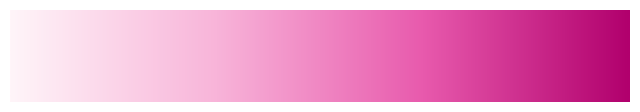

In [171]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import numpy as np

rose = LinearSegmentedColormap.from_list(
    "rose",
    ["#fff5f9", "#f8b4d9", "#e85aad", "#b1006d"]
)
mpl.colormaps.register(rose, name="rose", force=True)

# exemple d'affichage
gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1.2))
plt.imshow(gradient, aspect="auto", cmap=rose)
plt.axis("off")
plt.show()

In [258]:
denom_prost = vers_dictionnaire(pays_annee_par_motif(df_complet, "PROST", None, PAYS_LISTE))
denom_concept_prost = vers_dictionnaire(pays_annee_par_motif(df_complet, "CONCEPT_PROST", None, PAYS_LISTE))
denom_act_prost = vers_dictionnaire(pays_annee_par_motif(df_complet, "ACT_PROST", None, PAYS_LISTE))

In [259]:
denom_concept_prost

{'Belgique': [(2000, 119),
  (2001, 153),
  (2002, 171),
  (2003, 136),
  (2004, 114),
  (2005, 181),
  (2006, 208),
  (2007, 157),
  (2008, 161),
  (2009, 171),
  (2010, 125),
  (2011, 207),
  (2012, 201),
  (2013, 251),
  (2014, 206),
  (2015, 278),
  (2016, 337),
  (2017, 810),
  (2018, 725),
  (2019, 820),
  (2020, 666),
  (2021, 533),
  (2022, 558),
  (2023, 553),
  (2024, 331),
  (2025, 109)],
 'Canada': [(2000, 482),
  (2001, 423),
  (2002, 519),
  (2003, 1072),
  (2004, 1226),
  (2005, 790),
  (2006, 749),
  (2007, 710),
  (2008, 715),
  (2009, 634),
  (2010, 682),
  (2011, 904),
  (2012, 961),
  (2013, 1196),
  (2014, 1055),
  (2015, 771),
  (2016, 686),
  (2017, 565),
  (2018, 557),
  (2019, 532),
  (2020, 463),
  (2021, 451),
  (2022, 523),
  (2023, 413),
  (2024, 275),
  (2025, 121)],
 'France': [(2000, 882),
  (2001, 1730),
  (2002, 3052),
  (2003, 2636),
  (2004, 2553),
  (2005, 2673),
  (2006, 2546),
  (2007, 2274),
  (2008, 1975),
  (2009, 2223),
  (2010, 2989),
  (2011

In [264]:
def calculer_ratio(dict_numerateur: dict, dict_denominateur: dict) -> dict:
    ratio = {}
    for pays, paires in dict_numerateur.items():
        denom_pays = dict(dict_denominateur.get(pays, []))
        ratio[pays] = []
        for annee, n in paires:
            total = denom_pays.get(annee, 0)
            pct = (n / total * 10000) if total > 0 else 0.0
            ratio[pays].append((annee, pct))
    return ratio

In [265]:
ratio_prost = calculer_ratio(dict_prost, denom_prost)
ratio_concept_prost = calculer_ratio(dict_concept_prost, denom_concept_prost)

In [236]:
denom_concept_prost

{}

In [230]:
dict_prost

{None: [(2024, 2)],
 'Algérie': [(2015, 2), (2016, 1)],
 'Belgique': [(2016, 1), (2019, 3), (2020, 3), (2022, 1), (2024, 1)],
 'Canada': [(2000, 2),
  (2002, 3),
  (2003, 1),
  (2004, 2),
  (2008, 1),
  (2011, 2),
  (2013, 4),
  (2014, 2),
  (2015, 1),
  (2017, 1),
  (2019, 1),
  (2020, 3),
  (2022, 3),
  (2023, 2),
  (2024, 1)],
 'France': [(2000, 1),
  (2002, 1),
  (2005, 1),
  (2006, 3),
  (2009, 1),
  (2011, 2),
  (2012, 3),
  (2013, 8),
  (2014, 2),
  (2015, 1),
  (2017, 1),
  (2019, 5),
  (2020, 4),
  (2022, 1),
  (2023, 4),
  (2024, 2),
  (2025, 1)],
 'Suisse': [(2011, 2), (2014, 2), (2016, 1), (2017, 1), (2020, 1)]}

In [234]:
test_denom = (
    df_complet.select("id", "année", "pays", "PROST")
    .explode("pays")
    .filter(pl.col("année").is_between(2000, 2025))
    .explode("PROST")
    .drop_nulls(subset=["PROST"])
    .unique(subset=["id", "pays", "année"])
    .group_by(["pays", "année"])
    .agg(pl.len().alias("nb_total"))
    .sort(["pays", "année"])
)
print(test_denom.height)
print(test_denom.head(10))

247
shape: (10, 3)
┌──────┬───────┬──────────┐
│ pays ┆ année ┆ nb_total │
│ ---  ┆ ---   ┆ ---      │
│ str  ┆ i64   ┆ u32      │
╞══════╪═══════╪══════════╡
│ null ┆ 2000  ┆ 17       │
│ null ┆ 2001  ┆ 11       │
│ null ┆ 2002  ┆ 44       │
│ null ┆ 2003  ┆ 15       │
│ null ┆ 2004  ┆ 27       │
│ null ┆ 2005  ┆ 32       │
│ null ┆ 2006  ┆ 30       │
│ null ┆ 2007  ┆ 33       │
│ null ┆ 2008  ┆ 35       │
│ null ┆ 2009  ┆ 39       │
└──────┴───────┴──────────┘


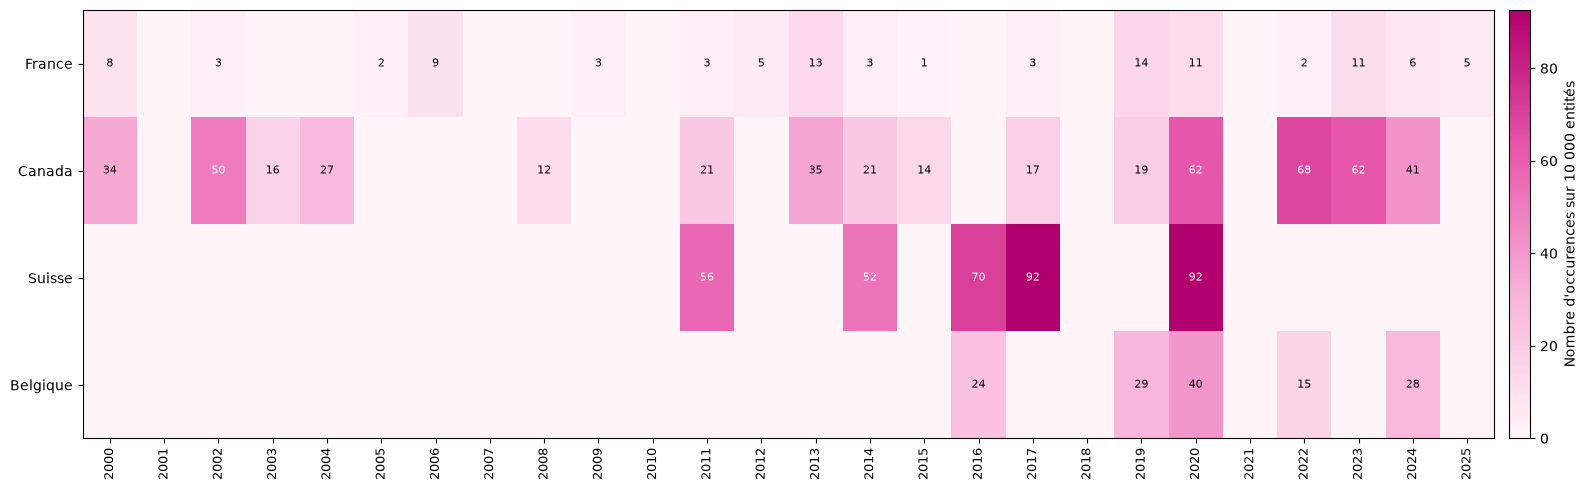

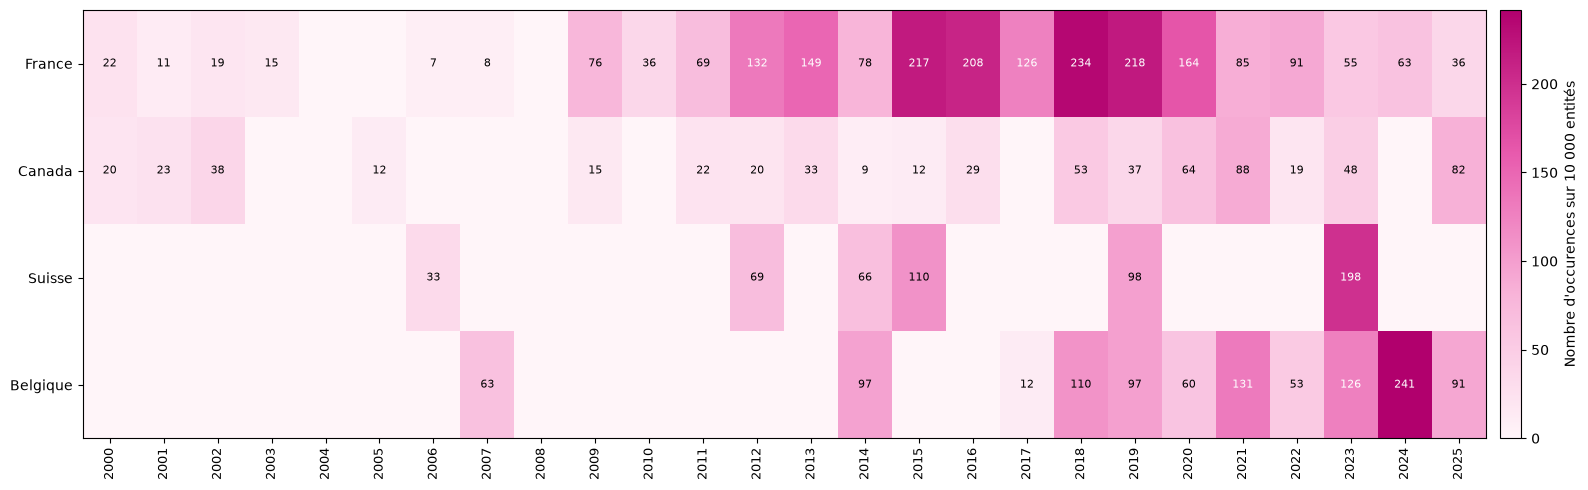

In [275]:
CONCEPT_PROST = ratio_concept_prost
PROST = ratio_prost

def to_long(d, label):
    rows = []
    for country, pairs in d.items():
        c = country if country is not None else "Non attribue"
        for year, n in pairs:
            rows.append({"pays": c, "annee": year, "n": n, "corpus": label})
    return pd.DataFrame(rows)

df = pd.concat([to_long(PROST, "PROST"), to_long(CONCEPT_PROST, "CONCEPT_PROST")], ignore_index=True)

def plot_heatmap(corpus_name, cmap, filename):
    sub = df[df.corpus == corpus_name]
    pivot = sub.pivot_table(index='pays', columns='annee', values='n', aggfunc='sum', fill_value=0)
    all_years = list(range(df['annee'].min(), df['annee'].max() + 1))
    pivot = pivot.reindex(columns=all_years, fill_value=0)
    pivot = pivot.reindex(index=PAYS_LISTE, fill_value=0)

    data = pivot.values
    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(data, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(all_years)))
    ax.set_xticklabels(all_years, rotation=90, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10)
    #ax.set_title(f"{corpus_name} - Nombre d'articles par pays et par annee", fontsize=13, fontweight='bold')

    vmax = data.max()
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if val > 0:
                color = "white" if val > vmax * 0.5 else "black"
                ax.text(j, i, int(val), ha='center', va='center', color=color, fontsize=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label("Nombre d'occurences sur 10 000 entités")
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

# Deux figures independantes
plot_heatmap("PROST", "rose", "fig_heatmap_PROST.png")
plot_heatmap("CONCEPT_PROST", "rose", "fig_heatmap_CONCEPT_PROST.png")

# A propos de la notion de racolage

In [276]:
long_racolage_concept = pays_annee_par_motif(df_complet, "CONCEPT_PROST", "racol")
long_racolage_act = pays_annee_par_motif(df_complet, "ACT_PROST", "racol")

In [277]:
dict_racolage_concept = vers_dictionnaire(long_racolage_concept)
dict_racolage_act = vers_dictionnaire(long_racolage_act)

In [278]:
ratio_racolage_concept = calculer_ratio(dict_racolage_concept, denom_concept_prost)
ratio_racolage_act = calculer_ratio(dict_racolage_act, denom_act_prost)

In [279]:
df = pd.concat([to_long(ratio_racolage_concept, "CONCEPT_PROST"), to_long(ratio_racolage_act, "ACT_PROST")], ignore_index=True)

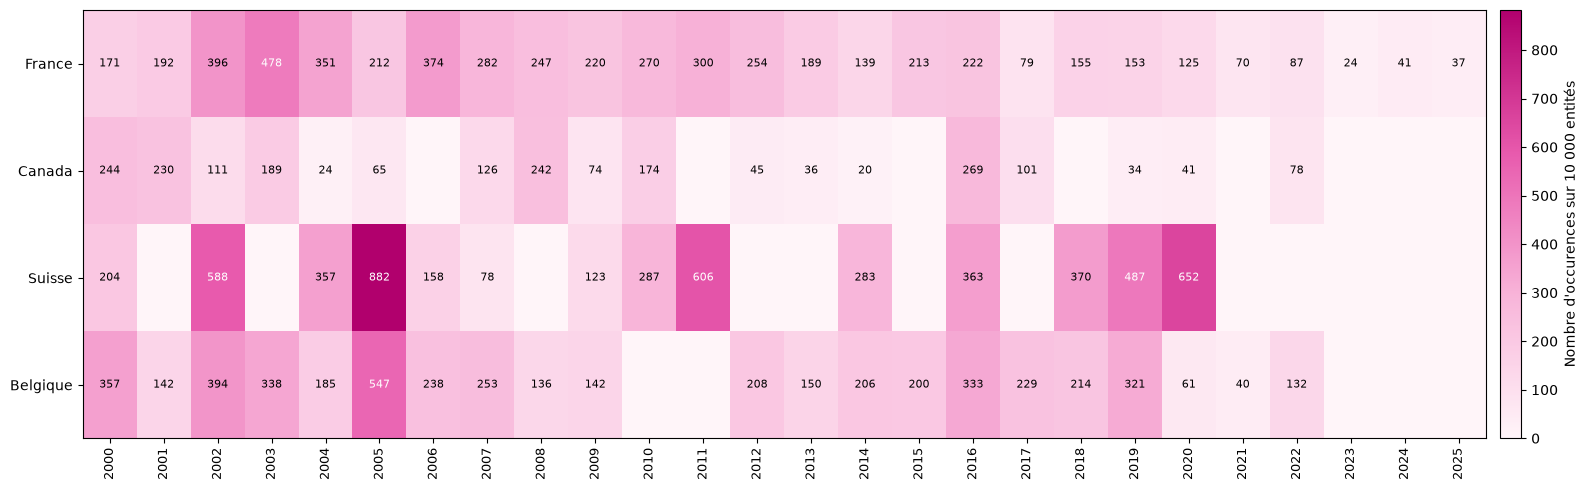

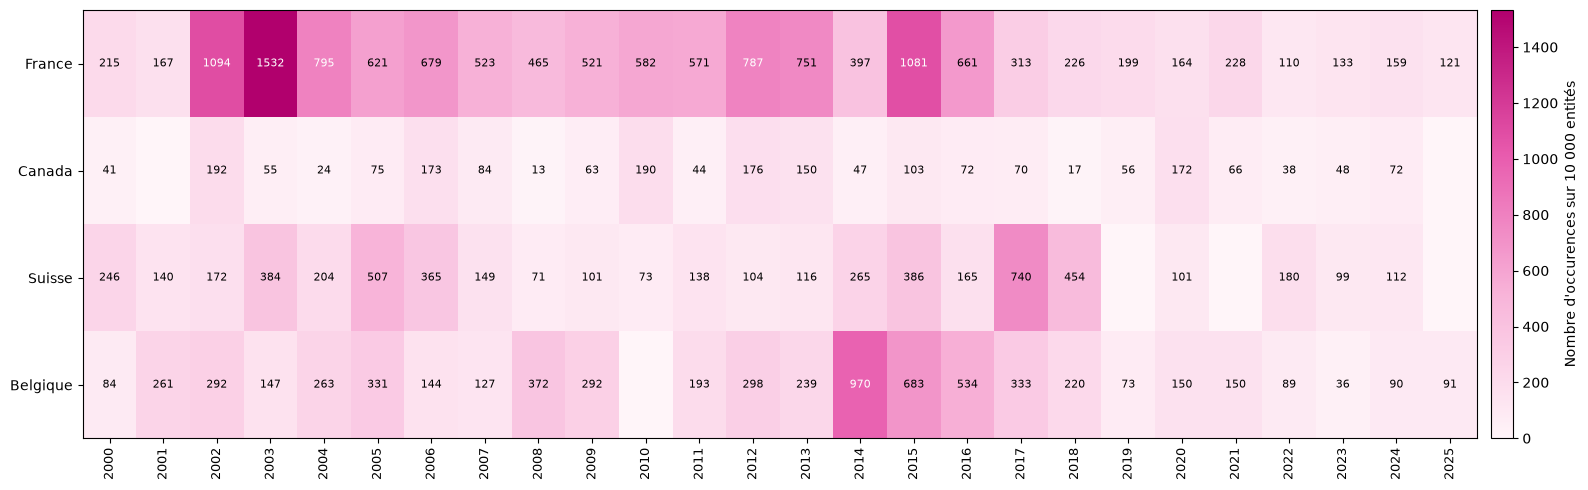

In [280]:
plot_heatmap("ACT_PROST", "rose", "fig_heatmap_racolage_PROST.png")
plot_heatmap("CONCEPT_PROST", "rose", "fig_heatmap_racolage_CONCEPT_PROST.png")

# Pour personne en situation de prostitution

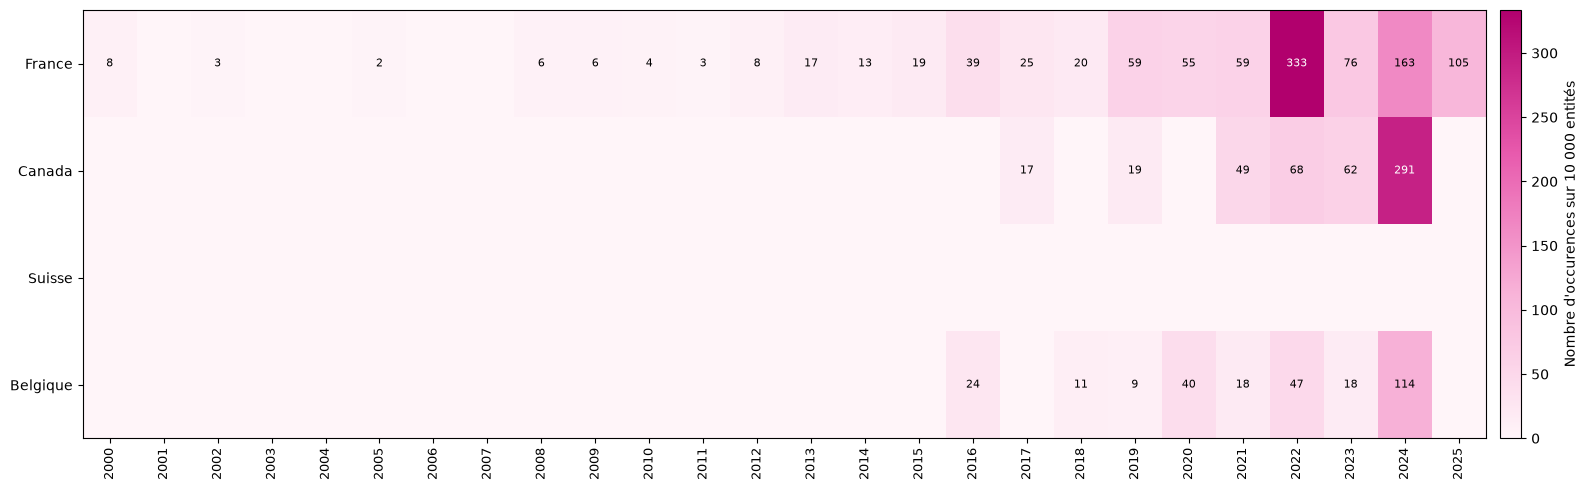

In [281]:
long_situation= pays_annee_par_motif(df_complet, "PROST", "personne_situation")
dict_situation = vers_dictionnaire(long_situation)
ratio_situation = calculer_ratio(dict_situation, denom_prost)
df = to_long(ratio_situation, "PROST")
plot_heatmap("PROST", "rose", "fig_heatmap_personne_situ.png")

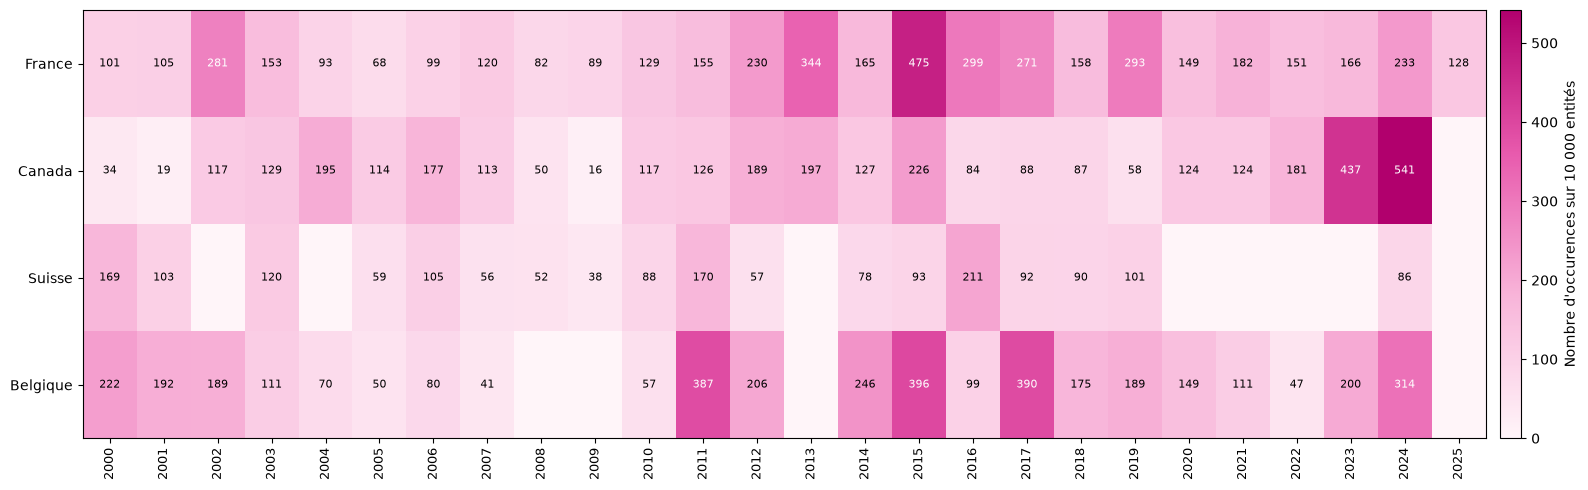

In [282]:
long_personne= pays_annee_par_motif(df_complet, "PROST", "personne_prost")
dict_personne = vers_dictionnaire(long_personne)
ratio_personne = calculer_ratio(dict_personne, denom_prost)
df = to_long(ratio_personne, "PROST")
plot_heatmap("PROST", "rose", "fig_heatmap_personne_prosti.png")

# Pour le genre des mots

In [184]:
import polars as pl
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------------------------------------------------------------------
# 0. Paramètres
# ---------------------------------------------------------------------------

PAYS_LISTE = ["France", "Canada", "Suisse", "Belgique"]
ANNEE_MIN, ANNEE_MAX = 2000, 2025

LABELS = ["Féminin", "Masculin", "Neutre", "Non genré / autre"]
COULEURS = ["#B1006D", "#E85AAD", "#F8B4D9", "#FC97C6"]

# ---------------------------------------------------------------------------
# 1. Chargement (on suppose que `df` existe déjà)
# ---------------------------------------------------------------------------
# df = pl.read_parquet("mon_corpus.parquet")


def compter_entites(df_source: pl.DataFrame, colonne: str) -> pl.DataFrame:
    """Nombre d'entités non nulles (colonne liste) par pays et par année."""
    return (
        df_source
        .select("id", "année", "pays", colonne)
        .explode("pays")
        .explode(colonne)
        .drop_nulls(subset=[colonne])
        .group_by(["pays", "année"])
        .agg(pl.len().alias("n"))
    )


def tableau_genre(df_source: pl.DataFrame, prefixe: str) -> pl.DataFrame:
    """
    Construit une table complète (grille pays x année, sans trou) avec
    les colonnes : pays, année, total, fem, mas, neu, non_genre.
    """
    total = compter_entites(df_source, prefixe).rename({"n": "total"})
    fem = compter_entites(df_source, f"{prefixe}f").rename({"n": "fem"})
    mas = compter_entites(df_source, f"{prefixe}m").rename({"n": "mas"})
    neu = compter_entites(df_source, f"{prefixe}n").rename({"n": "neu"})

    grille = pl.DataFrame({"pays": PAYS_LISTE}).join(
        pl.DataFrame({"année": list(range(ANNEE_MIN, ANNEE_MAX + 1))}),
        how="cross",
    )

    table = (
        grille
        .join(total, on=["pays", "année"], how="left")
        .join(fem, on=["pays", "année"], how="left")
        .join(mas, on=["pays", "année"], how="left")
        .join(neu, on=["pays", "année"], how="left")
        .fill_null(0)
    )

    table = table.with_columns(
        (pl.col("total") - pl.col("fem") - pl.col("mas") - pl.col("neu"))
        .clip(lower_bound=0)
        .alias("non_genre")
    )
    return table


def valeurs_pour(table: pl.DataFrame, pays: str, annee: int) -> list:
    ligne = table.filter((pl.col("pays") == pays) & (pl.col("année") == annee))
    if ligne.height == 0:
        return [0, 0, 0, 0]
    row = ligne.row(0, named=True)
    return [row["fem"], row["mas"], row["neu"], row["non_genre"]]


def construire_figure(table: pl.DataFrame, titre: str, nom_fichier: str) -> None:
    fig = make_subplots(
        rows=1, cols=4,
        specs=[[{"type": "domain"}] * 4],
        subplot_titles=PAYS_LISTE,
    )

    # Traces initiales (année de départ = ANNEE_MIN)
    for i, pays in enumerate(PAYS_LISTE):
        valeurs = valeurs_pour(table, pays, ANNEE_MIN)
        fig.add_trace(
            go.Pie(
                labels=LABELS,
                values=valeurs,
                marker_colors=COULEURS,
                hole=0.35,
                textinfo="percent",
                sort=False,
                name=pays,
            ),
            row=1, col=i + 1,
        )

    # Frames : une par année, contenant les 4 nouveaux camemberts
    frames = []
    for annee in range(ANNEE_MIN, ANNEE_MAX + 1):
        data_frame = [
            go.Pie(
                labels=LABELS,
                values=valeurs_pour(table, pays, annee),
                marker_colors=COULEURS,
                hole=0.35,
                textinfo="percent",
                sort=False,
            )
            for pays in PAYS_LISTE
        ]
        frames.append(go.Frame(data=data_frame, name=str(annee)))

    fig.frames = frames

    steps = [
        dict(
            method="animate",
            args=[
                [str(annee)],
                {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}},
            ],
            label=str(annee),
        )
        for annee in range(ANNEE_MIN, ANNEE_MAX + 1)
    ]

    fig.update_layout(
        title=titre,
        legend=dict(orientation="h", yanchor="bottom", y=-0.15, x=0.5, xanchor="center"),
        sliders=[
            dict(
                active=0,
                steps=steps,
                currentvalue={"prefix": "Année : "},
                pad={"t": 60},
            )
        ],
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,
                x=0.5, xanchor="center", y=1.15, yanchor="top",
                buttons=[
                    dict(
                        label="Lecture",
                        method="animate",
                        args=[None, {"frame": {"duration": 600, "redraw": True}, "fromcurrent": True}],
                    ),
                    dict(
                        label="Pause",
                        method="animate",
                        args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}],
                    ),
                ],
            )
        ],
        margin=dict(t=120, b=100),
    )

    fig.write_html(nom_fichier, auto_play=False)
    print(f"Fichier écrit : {nom_fichier}")


# ---------------------------------------------------------------------------
# 2. Construction des tables et génération des 2 fichiers HTML
# ---------------------------------------------------------------------------
table_prost = tableau_genre(df_complet, "PROST")
table_prox = tableau_genre(df_complet, "PROX")

construire_figure(table_prost, "Répartition du genre des entités PROST (2000-2025)", "genre_PROST.html")
construire_figure(table_prox, "Répartition du genre des entités PROX (2000-2025)", "genre_PROX.html")


Fichier écrit : genre_PROST.html
Fichier écrit : genre_PROX.html


# Pour le nombre des mots

In [185]:
# 0. Paramètres
# ---------------------------------------------------------------------------

PAYS_LISTE = ["France", "Canada", "Suisse", "Belgique"]
ANNEE_MIN, ANNEE_MAX = 2000, 2025

LABELS = ["Singulier", "Pluriel", "Non marqué / autre"]
COULEURS = ["#B1006D", "#E85AAD", "#F8B4D9", "#FC97C6"]

# ---------------------------------------------------------------------------
# 1. Chargement (on suppose que `df` existe déjà)
# ---------------------------------------------------------------------------
# df = pl.read_parquet("mon_corpus.parquet")


def compter_entites(df_source: pl.DataFrame, colonne: str) -> pl.DataFrame:
    """Nombre d'entités non nulles (colonne liste) par pays et par année."""
    return (
        df_source
        .select("id", "année", "pays", colonne)
        .explode("pays")
        .explode(colonne)
        .drop_nulls(subset=[colonne])
        .group_by(["pays", "année"])
        .agg(pl.len().alias("n"))
    )


def tableau_nombre(df_source: pl.DataFrame, prefixe: str) -> pl.DataFrame:
    """
    Construit une table complète (grille pays x année, sans trou) avec
    les colonnes : pays, année, total, sing, plur, non_marque.
    """
    total = compter_entites(df_source, prefixe).rename({"n": "total"})
    sing = compter_entites(df_source, f"{prefixe}s").rename({"n": "sing"})
    plur = compter_entites(df_source, f"{prefixe}pl").rename({"n": "plur"})

    grille = pl.DataFrame({"pays": PAYS_LISTE}).join(
        pl.DataFrame({"année": list(range(ANNEE_MIN, ANNEE_MAX + 1))}),
        how="cross",
    )

    table = (
        grille
        .join(total, on=["pays", "année"], how="left")
        .join(sing, on=["pays", "année"], how="left")
        .join(plur, on=["pays", "année"], how="left")
        .fill_null(0)
    )

    table = table.with_columns(
        (pl.col("total") - pl.col("sing") - pl.col("plur"))
        .clip(lower_bound=0)
        .alias("non_marque")
    )
    return table


def valeurs_pour(table: pl.DataFrame, pays: str, annee: int) -> list:
    ligne = table.filter((pl.col("pays") == pays) & (pl.col("année") == annee))
    if ligne.height == 0:
        return [0, 0, 0]
    row = ligne.row(0, named=True)
    return [row["sing"], row["plur"], row["non_marque"]]


def construire_figure(table: pl.DataFrame, titre: str, nom_fichier: str) -> None:
    fig = make_subplots(
        rows=1, cols=4,
        specs=[[{"type": "domain"}] * 4],
        subplot_titles=PAYS_LISTE,
    )

    for i, pays in enumerate(PAYS_LISTE):
        valeurs = valeurs_pour(table, pays, ANNEE_MIN)
        fig.add_trace(
            go.Pie(
                labels=LABELS,
                values=valeurs,
                marker_colors=COULEURS,
                hole=0.35,
                textinfo="percent",
                sort=False,
                name=pays,
            ),
            row=1, col=i + 1,
        )

    frames = []
    for annee in range(ANNEE_MIN, ANNEE_MAX + 1):
        data_frame = [
            go.Pie(
                labels=LABELS,
                values=valeurs_pour(table, pays, annee),
                marker_colors=COULEURS,
                hole=0.35,
                textinfo="percent",
                sort=False,
            )
            for pays in PAYS_LISTE
        ]
        frames.append(go.Frame(data=data_frame, name=str(annee)))

    fig.frames = frames

    steps = [
        dict(
            method="animate",
            args=[
                [str(annee)],
                {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}},
            ],
            label=str(annee),
        )
        for annee in range(ANNEE_MIN, ANNEE_MAX + 1)
    ]

    fig.update_layout(
        title=titre,
        legend=dict(orientation="h", yanchor="bottom", y=-0.15, x=0.5, xanchor="center"),
        sliders=[
            dict(
                active=0,
                steps=steps,
                currentvalue={"prefix": "Année : "},
                pad={"t": 60},
            )
        ],
        updatemenus=[
            dict(
                type="buttons",
                showactive=False,
                x=0.5, xanchor="center", y=1.15, yanchor="top",
                buttons=[
                    dict(
                        label="Lecture",
                        method="animate",
                        args=[None, {"frame": {"duration": 600, "redraw": True}, "fromcurrent": True}],
                    ),
                    dict(
                        label="Pause",
                        method="animate",
                        args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}],
                    ),
                ],
            )
        ],
        margin=dict(t=120, b=100),
    )

    fig.write_html(nom_fichier, auto_play=False)
    print(f"Fichier écrit : {nom_fichier}")


# ---------------------------------------------------------------------------
# 2. Construction des tables et génération des 2 fichiers HTML
# ---------------------------------------------------------------------------
table_prost = tableau_nombre(df_complet, "PROST")
table_prox = tableau_nombre(df_complet, "PROX")

construire_figure(table_prost, "Répartition singulier/pluriel des entités PROST (2000-2025)", "nombre_PROST.html")
construire_figure(table_prox, "Répartition singulier/pluriel des entités PROX (2000-2025)", "nombre_PROX.html")


Fichier écrit : nombre_PROST.html
Fichier écrit : nombre_PROX.html


In [186]:
"""
Liste des termes (entités PROST et PROX), classés par ordre décroissant de
fréquence, pour chaque genre (féminin / masculin / neutre) et chaque
nombre (singulier / pluriel), par pays.

Sortie :
    table_termes : polars.DataFrame, une ligne par (categorie, attribut,
    pays, terme), triée par fréquence décroissante à l'intérieur de chaque
    groupe (categorie + attribut + pays).

    -> exportable en CSV, ou convertible en liste de dictionnaires via
       table_termes.to_dicts()

Colonnes :
    categorie   PROST ou PROX
    attribut    Féminin / Masculin / Neutre / Singulier / Pluriel
    pays
    terme
    n           nombre d'occurrences du terme pour cet attribut, ce pays
    pct         % que représente ce terme parmi TOUTES les occurrences de
                cet attribut pour ce pays (n / total_attribut_pays * 100)
    rang        rang du terme au sein du groupe (1 = le plus fréquent)
"""


PAYS_LISTE = ["France", "Canada", "Suisse", "Belgique"]
ANNEE_MIN, ANNEE_MAX = 2000, 2025
CATEGORIES = ["PROST", "PROX"]

ATTRIBUTS = {
    "f": "Féminin",
    "m": "Masculin",
    "n": "Neutre",
    "s": "Singulier",
    "pl": "Pluriel",
}


def compter_termes(df_source: pl.DataFrame, colonne: str) -> pl.DataFrame:
    """Nombre d'occurrences de chaque terme, par pays, pour une colonne liste donnée."""
    return (
        df_source
        .filter(pl.col("année").is_between(ANNEE_MIN, ANNEE_MAX))
        .select("pays", colonne)
        .explode("pays")
        .filter(pl.col("pays").is_in(PAYS_LISTE))
        .explode(colonne)
        .drop_nulls(subset=[colonne])
        .filter(pl.col(colonne) != "")
        .rename({colonne: "terme"})
        .group_by(["pays", "terme"])
        .agg(pl.len().alias("n"))
    )


tables = []

for prefixe in CATEGORIES:
    for suffixe, label in ATTRIBUTS.items():
        colonne = f"{prefixe}{suffixe}"
        comptage = compter_termes(df_complet, colonne)

        if comptage.is_empty():
            continue

        total_par_pays = comptage.group_by("pays").agg(pl.col("n").sum().alias("total_pays"))

        table = (
            comptage
            .join(total_par_pays, on="pays", how="left")
            .with_columns((pl.col("n") / pl.col("total_pays") * 100).round(2).alias("pct"))
            .with_columns(
                pl.col("n")
                .rank(method="ordinal", descending=True)
                .over("pays")
                .alias("rang")
            )
            .with_columns(
                pl.lit(prefixe).alias("categorie"),
                pl.lit(label).alias("attribut"),
            )
            .select("categorie", "attribut", "pays", "terme", "n", "pct", "rang")
        )
        tables.append(table)

table_termes = pl.concat(tables).sort(
    ["categorie", "attribut", "pays", "rang"]
)

table_termes.write_csv("termes_par_genre_nombre.csv")
print(f"{table_termes.shape[0]} lignes écrites dans termes_par_genre_nombre.csv")

# Alternative : liste de dictionnaires
liste_dicts = table_termes.to_dicts()

1404 lignes écrites dans termes_par_genre_nombre.csv


In [188]:
table_termes.filter(
    (pl.col("categorie") == "PROX") &
    (pl.col("attribut") == "Féminin") &
    (pl.col("pays") == "Canada")
).head(10)

categorie,attribut,pays,terme,n,pct,rang
str,str,str,str,u32,f64,u32
"""PROX""","""Féminin""","""Canada""","""tenancière""",236,25.85,1
"""PROX""","""Féminin""","""Canada""","""proxénète""",176,19.28,2
"""PROX""","""Féminin""","""Canada""","""tête_dirigeant""",159,17.42,3
"""PROX""","""Féminin""","""Canada""","""monsieur_claude""",93,10.19,4
"""PROX""","""Féminin""","""Canada""","""protecteur""",51,5.59,5
"""PROX""","""Féminin""","""Canada""","""recruteuse""",41,4.49,6
"""PROX""","""Féminin""","""Canada""","""gang_rue""",40,4.38,7
"""PROX""","""Féminin""","""Canada""","""maquerelle""",32,3.5,8
"""PROX""","""Féminin""","""Canada""","""tête_réseau_prostitution""",22,2.41,9


In [187]:
ANNEE_MIN, ANNEE_MAX = 2000, 2025
CATEGORIES = ["PROST", "PROX"]
TOP_N = 10

ATTRIBUTS = {
    "f": "Féminin",
    "m": "Masculin",
    "n": "Neutre",
    "s": "Singulier",
    "pl": "Pluriel",
}


def compter_termes_global(df_source: pl.DataFrame, colonne: str) -> pl.DataFrame:
    """Nombre d'occurrences de chaque terme, tous pays confondus."""
    return (
        df_source
        .filter(pl.col("année").is_between(ANNEE_MIN, ANNEE_MAX))
        .select(colonne)
        .explode(colonne)
        .drop_nulls(subset=[colonne])
        .filter(pl.col(colonne) != "")
        .rename({colonne: "terme"})
        .group_by("terme")
        .agg(pl.len().alias("n"))
    )


tables = []

for prefixe in CATEGORIES:
    for suffixe, label in ATTRIBUTS.items():
        colonne = f"{prefixe}{suffixe}"
        comptage = compter_termes_global(df_complet, colonne)

        if comptage.is_empty():
            continue

        total = comptage.select(pl.col("n").sum()).item()

        table = (
            comptage
            .with_columns((pl.col("n") / total * 100).round(2).alias("pct"))
            .sort("n", descending=True)
            .with_columns((pl.int_range(pl.len()) + 1).alias("rang"))
            .filter(pl.col("rang") <= TOP_N)
            .with_columns(
                pl.lit(prefixe).alias("categorie"),
                pl.lit(label).alias("attribut"),
            )
            .select("categorie", "attribut", "terme", "n", "pct", "rang")
        )
        tables.append(table)

table_termes_global = pl.concat(tables).sort(["categorie", "attribut", "rang"])

table_termes_global.write_csv("top10_termes_genre_nombre_global.csv")
print(f"{table_termes_global.shape[0]} lignes écrites dans top10_termes_genre_nombre_global.csv")

liste_dicts_global = table_termes_global.to_dicts()


87 lignes écrites dans top10_termes_genre_nombre_global.csv


In [202]:


import polars as pl

# On ajoute l'index de ligne du dataframe ORIGINAL avant tout filtre/explode,
# pour pouvoir le retrouver après filtrage.
df_avec_index = df_complet.with_row_index("index_original")

# --- Niveau article : un index par ligne du df original concernée ---------
articles_concernes = (
    df_avec_index
    .filter(pl.col("année") == 2004)
    .explode("pays")
    .filter(pl.col("pays") == "Suisse")
    .filter(pl.col("PROSTs").is_not_null())
    .filter(pl.col("PROSTs").list.len() > 0)
    .select("index_original", "id", "PROXs")
)

liste_index = articles_concernes["index_original"].to_list()
print(f"{len(liste_index)} lignes concernées, index : {liste_index}")




47 lignes concernées, index : [4004, 5328, 11409, 12101, 14618, 15690, 16808, 20575, 21059, 23057, 23534, 23684, 26918, 28911, 38795, 44290, 44528, 53645, 59332, 67317, 68170, 78781, 80543, 86901, 87894, 88276, 92382, 92830, 93968, 96034, 101168, 101489, 111476, 120320, 127729, 132165, 138799, 151206, 158633, 159716, 164208, 166172, 166897, 167151, 169063, 172344, 172636]


In [215]:
entities[26918]

[{'ngram': 'prostituée',
  'text': 'prostituée',
  'start': 2521,
  'end': 2531,
  'labels': ['PROST'],
  'feats': ['Gender=Fem|Number=Sing'],
  'upos': ['NOUN'],
  'phrase': "Le sommet était atteint en 1999 - Jürg Wildberger n'était plus là - avec l'invention d'une histoire accusant le conseiller fédéral Kaspar Villiger d'avoir eu recours aux services d'une prostituée.",
  'start_phrase': 2335,
  'end_phrase': 2532},
 {'ngram': 'service_prostituée',
  'text': "services d'une prostituée",
  'start': 2506,
  'end': 2531,
  'labels': ['CONCEPT_PROST'],
  'feats': ['Gender=Masc|Number=Plur',
   '',
   'Gender=Fem|Number=Sing|Definite=Ind|PronType=Art',
   'Gender=Fem|Number=Sing'],
  'upos': ['NOUN', 'ADP', 'DET', 'NOUN'],
  'phrase': "Le sommet était atteint en 1999 - Jürg Wildberger n'était plus là - avec l'invention d'une histoire accusant le conseiller fédéral Kaspar Villiger d'avoir eu recours aux services d'une prostituée.",
  'start_phrase': 2335,
  'end_phrase': 2532}]